# DecPyMC-6-Systèmes Experts et Decisions Robustes
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jsboige/CoursIA/blob/main/MyIA.AI.Notebooks/Probas/DecisionTheory/PyMC/DecPyMC-6-Expert-Systems.ipynb)

## Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :
- Construire un **système expert bayesien** de diagnostic
- Appliquer le critere **Minimax** pour des decisions robustes
- Implementer le **Minimax Regret** (Savage, 1951)
- Utiliser le critere **Hurwicz** pour ajuster le niveau d'optimisme
- Realiser une **analyse de sensibilite** pour tester la robustesse

**Prerequis** : DecPyMC-4 (reseaux de decision), DecPyMC-5 (valeur de l'information)

**Duree estimee** : 50 minutes

---

| Notebook précédent | Notebook suivant |
|--------------------|------------------|
| [DecPyMC-5 - Valeur de l'information](DecPyMC-5-Value-Information.ipynb) | [DecPyMC-7 - Decisions séquentielles](DecPyMC-7-Sequential.ipynb) |

## 1. Systèmes Experts : Architecture

Un **système expert** simule le raisonnement d'un expert humain :
- **Base de connaissances** : règles, CPTs, priors
- **Moteur d'inference** : chainage avant, Bayes
- **Interface explicative** : justification des conclusions

### Jalons historiques

| Système | Annee | Domaine | Innovation cle |
|---------|-------|---------|----------------|
| DENDRAL | 1965 | Chimie | Premier système expert |
| MYCIN | 1976 | Medical | Facteurs de certitude, 600 règles |
| PROSPECTOR | 1979 | Geologie | Premiers reseaux bayesiens |
| R1/XCON | 1982 | Config VAX | Premier succes commercial |
| CLIPS | 1985 | General | Langage de règles public, chainage avant/arriere |

### Pourquoi l'evolution vers le probabiliste ?

Les systèmes a base de règles (MYCIN, CLIPS) utilisaient des **facteurs de certitude** ad hoc (Buchanan & Shortliffe, 1984) qui violaient les axiomes de probabilite. Par exemple, MYCIN combinait deux evidences avec une formule heuristique qui pouvait donner des résultats incoherents (P(A et B) > P(A)). L'approche bayesienne (Pearl, 1988) a resolu ces problemes en :

1. **Garantissant la coherence** : les probabilites satisfont les axiomes de Kolmogorov
2. **Traitant l'incertitude** naturellement via le theoreme de Bayes
3. **Permettant l'apprentissage** : les paramètres peuvent etre inferez a partir de données
4. **Facilitant l'explication** : on peut tracer le chemin d'inference

### Architecture type d'un système expert bayesien

```
+------------------+       +-------------------+       +--------------------+
|   Observations   | ----> |   Moteur d'       | ----> |    Decision        |
|  (symptomes,     |       |   inference       |       |  (diagnostic,      |
|   capteurs,      |       |   bayesien        |       |   action optimale) |
|   signaux)       |       |                   |       |                    |
+------------------+       +-------------------+       +--------------------+
                                    ^
                                    |
                           +--------+--------+
                           |   Base de       |
                           |   connaissances |
                           |  (priors, CPTs, |
                           |   likelihoods)  |
                           +-----------------+
```

Le **moteur d'inference bayesien** propage les observations vers les variables latentes via le theoreme de Bayes : $P(\text{cause} \mid \text{symptomes}) \propto P(\text{symptomes} \mid \text{cause}) \times P(\text{cause})$.

Les systèmes experts classiques souffraient de **fragilite** et de **mauvaise gestion de l'incertitude**.
L'approche bayesienne (Pearl, 1988) a resolu ces problemes.

### Schema : le système expert bayesien

Le diagramme reprend l'architecture decrite ci-dessus : les observations alimentent le moteur d'inference, qui produit la decision ; la base de connaissances (priors, CPTs, vraisemblances) paramètre l'inference.

```mermaid
flowchart LR
    O["Observations (symptomes, capteurs, signaux)"] --> M["Moteur d'inference bayesien"]
    M --> D["Decision (diagnostic, action optimale)"]
    KB["Base de connaissances (priors, CPTs, likelihoods)"] --> M
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
print("Imports OK")

Imports OK


## 2. Mini-système expert de diagnostic

On construit un système expert bayesien pour le diagnostic medical.
4 maladies, 4 symptomes, avec vraisemblances P(symptome|maladie).

Symptomes observes : fievre, toux, fatigue

Diagnostic (posterieurs) :
  Grippe     :  67.7%
  Covid      :  30.5%
  Rhume      :   1.8%
  Allergie   :   0.0%


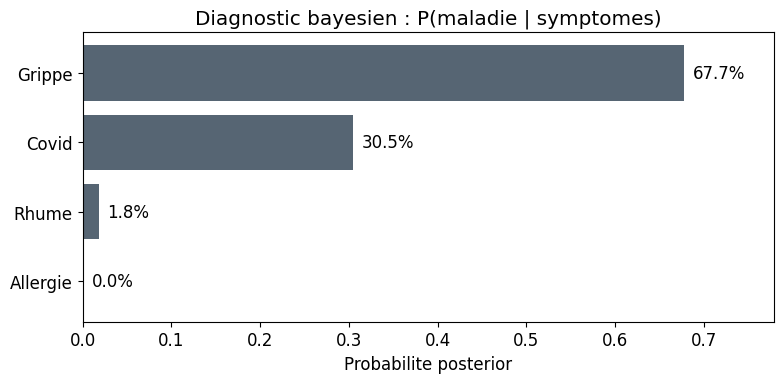

In [2]:
class MiniExpertSystem:
    """Systeme expert bayesien de diagnostic."""
    
    def __init__(self):
        self.maladies = ["Grippe", "Rhume", "Covid", "Allergie"]
        self.symptomes = ["fievre", "toux", "fatigue", "eternuements"]
        
        # Priors
        self.priors = np.array([0.30, 0.50, 0.15, 0.05])
        
        # Vraisemblances P(symptome|maladie)
        self.likelihoods = np.array([
            # fievre, toux, fatigue, eternuements
            [0.90, 0.80, 0.90, 0.30],  # Grippe
            [0.30, 0.60, 0.40, 0.90],  # Rhume
            [0.85, 0.75, 0.80, 0.20],  # Covid
            [0.05, 0.30, 0.20, 0.95],  # Allergie
        ])
    
    def diagnose(self, observed):
        """Calcule les posteriors P(maladie|symptomes observes)."""
        observed_idx = [self.symptomes.index(s) for s in observed]
        absent_idx = [i for i in range(len(self.symptomes)) if i not in observed_idx]
        
        # P(symptomes|maladie) = produit des P(s_i|maladie)
        likelihood = np.ones(len(self.maladies))
        for i in observed_idx:
            likelihood *= self.likelihoods[:, i]
        for i in absent_idx:
            likelihood *= (1 - self.likelihoods[:, i])
        
        # Bayes
        unnormalized = self.priors * likelihood
        posteriors = unnormalized / unnormalized.sum()
        return posteriors


expert = MiniExpertSystem()
symptomes_obs = ["fievre", "toux", "fatigue"]
posteriors = expert.diagnose(symptomes_obs)

print(f"Symptomes observes : {', '.join(symptomes_obs)}\n")
print("Diagnostic (posterieurs) :")
order = np.argsort(-posteriors)
for i in order:
    print(f"  {expert.maladies[i]:10s} : {posteriors[i]:6.1%}")

# Visualisation des posteriors (matplotlib, SOTA #3801 : vrai rendu, pas un substitut ASCII)
sorted_maladies = [expert.maladies[i] for i in order]
sorted_posteriors = posteriors[order]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(sorted_maladies[::-1], sorted_posteriors[::-1], color="#2c3e50", alpha=0.8)
ax.set_xlabel("Probabilite posterior")
ax.set_title("Diagnostic bayesien : P(maladie | symptomes)")
for i, v in enumerate(sorted_posteriors[::-1]):
    ax.text(v + 0.01, i, f"{v:.1%}", va="center")
ax.set_xlim(0, float(sorted_posteriors.max()) * 1.15)
plt.tight_layout()
plt.show()

### Visualisation de la matrice de vraisemblance

La **matrice de vraisemblance** $P(\text{symptome} \mid \text{maladie})$ est le coeur du système expert. Elle encode le profil diagnostique de chaque maladie. Une heatmap permet d'identifier rapidement les ** signatures symptomatiques** :

- Les **lignes** representent les maladies (profils diagnostiques)
- Les **colonnes** representent les symptomes (pouvoir discriminant)
- Les **valeurs elevees** (> 0.8) indiquent des symptomes fortement associes
- Les **valeurs faibles** (< 0.2) indiquent des symptomes rares pour cette maladie

Cette visualisation est essentielle pour valider la base de connaissances du système expert avant de l'utiliser pour le diagnostic.

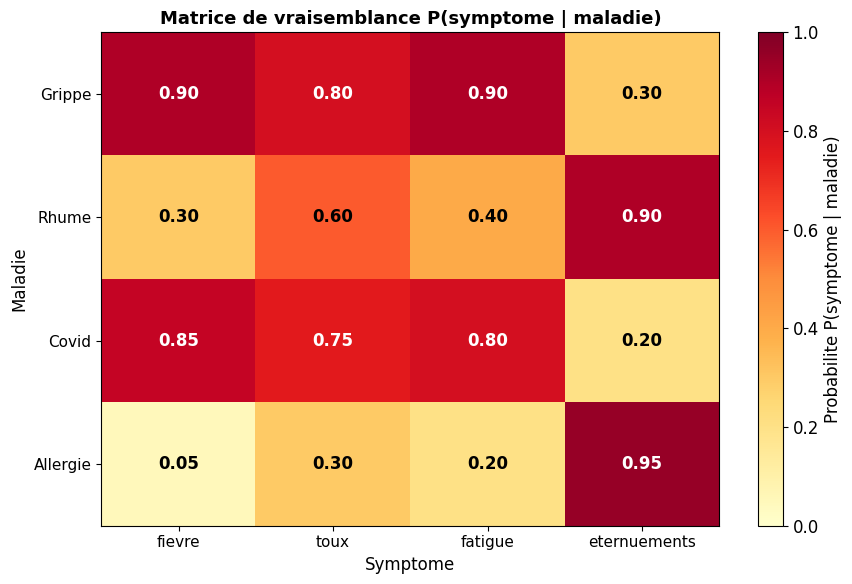

La matrice de vraisemblance revele les profils diagnostiques de chaque maladie :
- Grippe/Covid : fievre et fatigue elevees (profil systemic)
- Allergie : eternuements dominant (profil localise)
- Rhume : profil mixte avec toux et eternuements


In [3]:
# Visualisation de la matrice de vraisemblance P(symptome | maladie)
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(expert.likelihoods, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")

# Annotations
ax.set_xticks(range(len(expert.symptomes)))
ax.set_yticks(range(len(expert.maladies)))
ax.set_xticklabels(expert.symptomes, fontsize=11)
ax.set_yticklabels(expert.maladies, fontsize=11)
ax.set_xlabel("Symptome")
ax.set_ylabel("Maladie")
ax.set_title("Matrice de vraisemblance P(symptome | maladie)", fontsize=13, fontweight="bold")

# Valeurs dans les cellules
for i in range(len(expert.maladies)):
    for j in range(len(expert.symptomes)):
        val = expert.likelihoods[i, j]
        color = "white" if val > 0.65 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color=color, fontsize=12, fontweight="bold")

plt.colorbar(im, ax=ax, label="Probabilite P(symptome | maladie)")
plt.tight_layout()
plt.show()

print("La matrice de vraisemblance revele les profils diagnostiques de chaque maladie :")
print("- Grippe/Covid : fievre et fatigue elevees (profil systemic)")
print("- Allergie : eternuements dominant (profil localise)")
print("- Rhume : profil mixte avec toux et eternuements")

### Interpretation

La **Grippe** est la plus probable car les 3 symptomes (fievre, toux, fatigue) correspondent
bien au profil (90%, 80%, 90%). L'**absence d'eternuements** penalise le Rhume (90% -> non observe)
et l'Allergie (95% -> non observe).

## 3. Critere Minimax

Quand les probabilites sont inconnues ou peu fiables, on utilise des critères robustes.

$$a^* = \arg\max_a \min_s U(a, s)$$

On choisit l'action qui **maximise l'utilite dans le pire cas**.

In [4]:
def minimax_decision(actions, states, U):
    """Retourne (meilleure action, valeur du pire cas)."""
    worst_per_action = U.min(axis=1)  # min sur les etats pour chaque action
    best_idx = np.argmax(worst_per_action)
    return actions[best_idx], worst_per_action[best_idx]


# Scenario d'investissement
actions_inv = ["Obligations", "Actions", "Immobilier", "Cash"]
states_inv = ["Recession", "Stable", "Croissance"]
U_inv = np.array([
    [30000, 40000, 50000],   # Obligations
    [-20000, 50000, 120000], # Actions
    [-10000, 30000, 80000],  # Immobilier
    [20000, 20000, 20000]    # Cash
])

# Afficher la table
print("Analyse Minimax :\n")
header = f"{'Action':15s} | " + " | ".join(f"{s:>10s}" for s in states_inv) + " | Min"
print(header)
print("-" * len(header))

for a, action in enumerate(actions_inv):
    worst = U_inv[a].min()
    vals = " | ".join(f"{U_inv[a, s]:10.0f}" for s in range(len(states_inv)))
    print(f"{action:15s} | {vals} | {worst:8.0f}")

best_mm, val_mm = minimax_decision(actions_inv, states_inv, U_inv)
print(f"\n=> Minimax : {best_mm} (pire cas = {val_mm:.0f})")

Analyse Minimax :

Action          |  Recession |     Stable | Croissance | Min
------------------------------------------------------------
Obligations     |      30000 |      40000 |      50000 |    30000
Actions         |     -20000 |      50000 |     120000 |   -20000
Immobilier      |     -10000 |      30000 |      80000 |   -10000
Cash            |      20000 |      20000 |      20000 |    20000

=> Minimax : Obligations (pire cas = 30000)


### Interpretation détaillée du critère Minimax

**Analyse du tableau :**

| Action | Pire cas | Raisonnement |
|--------|----------|--------------|
| Obligations | 30k (récession) | Même en récession, rendement positif |
| Actions | -20k (récession) | Volatile, peut perdre |
| Immobilier | -10k (récession) | Moins volatil que les actions |
| Cash | 20k (partout) | Garanti mais faible |

**Décision Minimax : Obligations** -- le pire cas (30k) est le meilleur parmi tous les pires cas.

**Critique du Minimax :**
- Ignore complètement les scénarios favorables (les Actions montent à 120k en croissance)
- Trop pessimiste si la récession est peu probable (P < 10%)
- Recommandé pour les investisseurs ne pouvant tolérer **aucune perte** (fonds de retraite, capital de sécurité)

**Lien avec la théorie des jeux** : En jeu à somme nulle, Minimax est la stratégie optimale (théorème de Von Neumann, 1928). L'adversaire choisit réellement le pire état.

### Quand utiliser Minimax ?

| Situation | Pourquoi |
|-----------|----------|
| Erreurs catastrophiques | Pire cas inacceptable |
| Adversaire reel | L'autre optimise contre vous |
| Incertitude totale | Aucune probabilite fiable |
| Decision irreversible | Pas de seconde chance |

### Quand eviter Minimax ?

Le Minimax est trop pessimiste dans de nombreuses situations. Le tableau suivant identifie les cas ou un autre critere est plus adapte :

| Situation | Pourquoi eviter | Meilleur critere |
|-----------|-----------------|------------------|
| Probabilites fiables | Ignore l'information disponible | **Max EU** |
| Scénarios favorables probables | Rate les opportunites | **Hurwicz** (gamma > 0.5) |
| Regret plus important que perte | Minimax ne distingue pas "perdre 10k" de "rater un gain de 10k" | **Minimax Regret** |
| Decision reversible | On peut corriger si l'etat est favorable | **Max EU** ou **Hurwicz** |
| Plusieurs etats intermediaires | Ne regarde que le pire etat | **Minimax Regret** |

> **Règle pratique** : Si Minimax et Minimax Regret recommandent des actions différentes, c'est que le pire cas n'est pas la seule dimension a considerer. Analysez le **regret** et les **etats intermediaires** avant de choisir.

## 4. Critere Minimax Regret (Savage, 1951)

Le **regret** mesure l'ecart avec ce qu'on aurait pu faire de mieux :

$$\text{Regret}(a, s) = \max_{a'} U(a', s) - U(a, s)$$

$$a^* = \arg\min_a \max_s \text{Regret}(a, s)$$

In [5]:
def minimax_regret_decision(actions, states, U):
    """Retourne (meilleure action, max_regret, matrice_regret)."""
    best_per_state = U.max(axis=0)  # meilleure action pour chaque etat
    regret = best_per_state[np.newaxis, :] - U  # matrice de regret
    max_regret_per_action = regret.max(axis=1)
    best_idx = np.argmin(max_regret_per_action)
    return actions[best_idx], max_regret_per_action[best_idx], regret


best_mr, max_mr, regret_mat = minimax_regret_decision(actions_inv, states_inv, U_inv)

print("Matrice de Regret :\n")
header = f"{'Action':15s} | " + " | ".join(f"{s:>10s}" for s in states_inv) + " | MaxReg"
print(header)
print("-" * len(header))

for a, action in enumerate(actions_inv):
    vals = " | ".join(f"{regret_mat[a, s]:10.0f}" for s in range(len(states_inv)))
    print(f"{action:15s} | {vals} | {regret_mat[a].max():8.0f}")

print(f"\n=> Minimax Regret : {best_mr} (max regret = {max_mr:.0f})")

Matrice de Regret :

Action          |  Recession |     Stable | Croissance | MaxReg
---------------------------------------------------------------
Obligations     |          0 |      10000 |      70000 |    70000
Actions         |      50000 |          0 |          0 |    50000
Immobilier      |      40000 |      20000 |      40000 |    40000
Cash            |      10000 |      30000 |     100000 |   100000

=> Minimax Regret : Immobilier (max regret = 40000)


### Exercice : Minimax et Minimax Regret pour un choix de poste

Vous avez recu **4 offres d'emploi** et vous etes incertain(e) de l'evolution economique.
Vous decidez d'utiliser les critères **Minimax** et **Minimax Regret** pour faire votre choix.

**Offres d'emploi** et utilite estimee (en kEUR/an, après impots et cout de vie) :

| Offre | Recession | Stable | Boom |
|-------|-----------|--------|------|
| Start-up tech | 25 | 55 | 110 |
| Grande entreprise | 40 | 50 | 60 |
| Fonction publique | 38 | 38 | 38 |
| Consulting | 20 | 60 | 95 |

**Consignes** :
- Construire la matrice d'utilite (4 actions x 3 etats)
- Appliquer le **critere Minimax** : trouver l'action qui maximise le gain dans le pire cas
- Construire la **matrice de regret** : Regret(a, s) = max_a' U(a', s) - U(a, s)
- Appliquer le **critere Minimax Regret** : trouver l'action qui minimise le regret maximal
- Afficher un tableau comparatif des deux critères

**Indices** :
- # Indice : Reprenez les fonctions `minimax_decision` et `minimax_regret_decision` définies ci-dessus
- # Étape 1 : Définir les actions (offres), les etats (scénarios economiques) et la matrice U
- # Étape 2 : Appeler `minimax_decision(actions, states, U)` pour obtenir la decision Minimax
- # Étape 3 : Appeler `minimax_regret_decision(actions, states, U)` pour obtenir la decision Minimax Regret
- # Étape 4 : Afficher la matrice de regret et comparer les deux decisions

In [6]:
# Exercice : Minimax et Minimax Regret - choix de poste

# Etape 1 : Definir les actions, etats et matrice d'utilite
actions_job = ["Start-up tech", "Grande entreprise", "Fonction publique", "Consulting"]
states_econ = ["Recession", "Stable", "Boom"]
# TODO etudiant : completer la matrice d'utilite (4x3) d'apres le tableau ci-dessus
# Indice : chaque ligne = une offre, chaque colonne = un scenario economique
U_job = None  # TODO etudiant : np.array([[...], [...], [...], [...]])

# Etape 2 : Appliquer le critere Minimax
# TODO etudiant : utiliser la fonction minimax_decision() definie plus haut
result_minimax = None  # TODO etudiant

# Etape 3 : Construire la matrice de regret et appliquer Minimax Regret
# TODO etudiant : utiliser la fonction minimax_regret_decision() definie plus haut
result_regret = None  # TODO etudiant

# Etape 4 : Afficher les resultats
# TODO etudiant : afficher un tableau comparatif avec la matrice de regret
# et les decisions des deux criteres

print("Exercice a completer : Minimax et Minimax Regret pour un choix de poste")

Exercice a completer : Minimax et Minimax Regret pour un choix de poste


### Interpretation détaillée du Minimax Regret

**Pourquoi l'Immobilier ?** Le regret maximal de l'immobilier est de 40k, le plus faible de toutes les actions :
- En récession : regret = 40k (on aurait dû prendre Obligations)
- En stable : regret = 20k (on aurait dû prendre Actions)
- En croissance : regret = 40k (on aurait dû prendre Actions)

**Comparaison avec les autres actions :**

| Action | Max Regret | Profil |
|--------|-----------|--------|
| Obligations | 70k | Très regrettable en croissance (on rate 70k) |
| Actions | 50k | Regrettable en récession (on perd 50k vs Obligations) |
| **Immobilier** | **40k** | **Compromis : jamais très loin de l'optimal** |
| Cash | 100k | Très regrettable dans tous les scénarios favorables |

**Leçon clé** : Le Minimax Regret capture l'**opportunité manquée**, pas le résultat absolu. Une action avec un bon résultat dans tous les états peut avoir un regret élevé si une autre action fait beaucoup mieux dans un état spécifique.

**Exemple concret** : Si vous choisissez Obligations et que l'économie croît, votre regret est de 70k (120k - 50k). Vous ne perdez pas d'argent, mais vous ratez une opportunité de gain important.

### Trois critères, trois decisions

| Critere | Decision | Philosophie |
|---------|----------|-------------|
| Max EU | Actions | Confiance dans les probabilites |
| Minimax | Obligations | Ne jamais perdre |
| Minimax Regret | Immobilier | Eviter de trop se tromper |

## 5. Comparaison complete des critères

In [7]:
# Comparaison avec probabilites hypothetiques
probs = np.array([0.25, 0.50, 0.25])  # Recession, Stable, Croissance

print("=== Comparaison des Criteres ===\n")
print(f"Probabilites : {', '.join(f'{s}={p:.0%}' for s, p in zip(states_inv, probs))}\n")

# 1. Max EU
eu = U_inv @ probs  # EU pour chaque action (4x3 @ 3 = 4)
print("1. Maximisation EU :")
for a, action in enumerate(actions_inv):
    print(f"   E[U({action})] = {eu[a]:.0f}")
best_eu_idx = np.argmax(eu)
print(f"   => {actions_inv[best_eu_idx]}\n")

# 2. Minimax
best_mm, val_mm = minimax_decision(actions_inv, states_inv, U_inv)
print(f"2. Minimax : {best_mm} (pire cas = {val_mm:.0f})\n")

# 3. Minimax Regret
best_mr, max_mr, _ = minimax_regret_decision(actions_inv, states_inv, U_inv)
print(f"3. Minimax Regret : {best_mr} (max regret = {max_mr:.0f})\n")

print("=== Resume ===")
print(f"Max EU         : {actions_inv[best_eu_idx]}")
print(f"Minimax        : {best_mm}")
print(f"Minimax Regret : {best_mr}")

=== Comparaison des Criteres ===

Probabilites : Recession=25%, Stable=50%, Croissance=25%

1. Maximisation EU :
   E[U(Obligations)] = 40000
   E[U(Actions)] = 50000
   E[U(Immobilier)] = 32500
   E[U(Cash)] = 20000
   => Actions

2. Minimax : Obligations (pire cas = 30000)

3. Minimax Regret : Immobilier (max regret = 40000)

=== Resume ===
Max EU         : Actions
Minimax        : Obligations
Minimax Regret : Immobilier


### Arbre de décision pour choisir le bon critère

Quand les trois critères recommandent des actions différentes, le choix du critère dépend du **profil de risque** et de la **confiance dans les probabilités** :

```
Avez-vous confiance dans les probabilites ?
    |
    +-- Oui --> Max EU (Actions)
    |
    +-- Non --> Le pire cas est-il catastrophique ?
                    |
                    +-- Oui --> Minimax (Obligations)
                    |            (erreurs irreversibles, securite)
                    |
                    +-- Non --> Minimax Regret (Immobilier)
                                 (eviter les regrets, compromis)
```

**Application pratique :**

| Contexte | Critère recommandé | Raison |
|----------|-------------------|--------|
| Fonds de retraite | Minimax | Capital à protéger, pas de risque |
| Portefeuille diversifié | Max EU | Horizon long, probabilités fiables |
| Investissement ponctuel | Minimax Regret | Éviter les regrets |
| Chirurgie médicale | Minimax | Erreur = catastrophe |
| Choix de restaurant | Max EU | Faible enjeu, préférences connues |

> **Point clé** : Quand tous les critères convergent vers la même action, la décision est **robuste**. Quand ils divergent, la divergence est un signal d'incertitude réelle qu'il faut communiquer au décideur.

### Schema : arbre de sélection du critere de decision

Le même arbre de decision, rendu sous forme de graphe : selon la confiance dans les probabilites et la gravite du pire cas, on retient un critere différent.

```mermaid
flowchart TD
    Q["Avez-vous confiance dans les probabilites ?"]
    Q -->|"Oui"| EU["Max EU (Actions)"]
    Q -->|"Non"| C["Le pire cas est-il catastrophique ?"]
    C -->|"Oui"| MM["Minimax (Obligations) - erreurs irreversibles, securite"]
    C -->|"Non"| MR["Minimax Regret (Immobilier) - eviter les regrets, compromis"]
```

## 6. Critere Hurwicz : compromis optimisme/pessimisme

$$H(a) = \gamma \cdot \max_s U(a,s) + (1-\gamma) \cdot \min_s U(a,s)$$

Le paramètre $\gamma$ contrôle le niveau d'optimisme.

In [8]:
def hurwicz_decision(actions, U, gamma):
    """Critere Hurwicz avec coefficient gamma."""
    h = gamma * U.max(axis=1) + (1 - gamma) * U.min(axis=1)
    best_idx = np.argmax(h)
    return actions[best_idx], h[best_idx]


print("Critere Hurwicz selon gamma :\n")
print(f"{'gamma':>5s}  | {'Decision':14s} | H(a*)")
print("-" * 35)

gammas = np.arange(0, 1.01, 0.2)
for g in gammas:
    best, val = hurwicz_decision(actions_inv, U_inv, g)
    print(f"{g:5.1f}  | {best:14s} | {val:8.0f}")

print("\n=> Pessimiste (gamma=0) = Minimax, Optimiste (gamma=1) = Maximax")

Critere Hurwicz selon gamma :

gamma  | Decision       | H(a*)
-----------------------------------
  0.0  | Obligations    |    30000
  0.2  | Obligations    |    34000
  0.4  | Obligations    |    38000
  0.6  | Actions        |    64000
  0.8  | Actions        |    92000
  1.0  | Actions        |   120000

=> Pessimiste (gamma=0) = Minimax, Optimiste (gamma=1) = Maximax


### Interpretation détaillée du critère Hurwicz

**Point de basculement** : Entre gamma = 0.4 et gamma = 0.6, la décision change d'Obligations à Actions.

**Calcul formel du seuil** : En égalisant les scores Hurwicz :
- H(Obligations) = gamma * 50000 + (1-gamma) * 30000 = 30000 + 20000*gamma
- H(Actions) = gamma * 120000 + (1-gamma) * (-20000) = -20000 + 140000*gamma

Seuil : 30000 + 20000*gamma = -20000 + 140000*gamma → gamma* = 50/120 = **0.417**

**Observation importante** : L'Immobilier n'est **jamais optimal** selon Hurwicz !

Pourquoi ? Le critère Hurwicz ne considère que le min et le max de chaque action :
- Immobilier : min=-10k, max=80k
- Actions : min=-20k, max=120k (domine pour gamma élevé)
- Obligations : min=30k, max=50k (domine pour gamma bas)

**Limite du critère Hurwicz** : Il ignore les **états intermédiaires**. Pourtant, Minimax Regret recommandait l'Immobilier car ses résultats intermédiaires sont plus favorables. Chaque critère capture une dimension différente de la décision.

| gamma | Décision | Profil du décideur |
|-------|----------|-------------------|
| 0.0 - 0.4 | Obligations | Prudent, prépare le pire |
| ~0.417 | **Seuil** | Zone de transition |
| 0.4 - 1.0 | Actions | Confiant, vise le meilleur |

### Visualisation : decision vs gamma

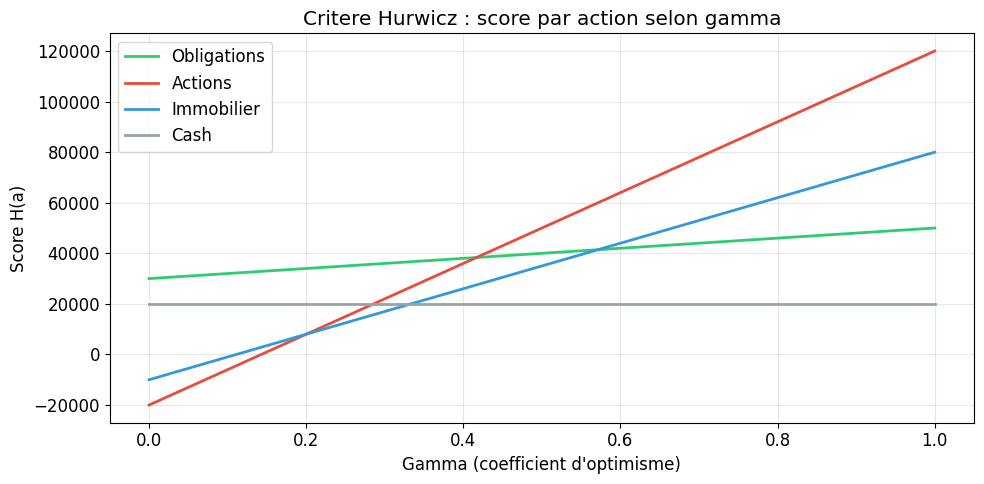

In [9]:
gammas_fine = np.linspace(0, 1, 200)
decisions = []
h_values = {a: [] for a in actions_inv}

for g in gammas_fine:
    best, _ = hurwicz_decision(actions_inv, U_inv, g)
    decisions.append(best)
    h = g * U_inv.max(axis=1) + (1 - g) * U_inv.min(axis=1)
    for i, a in enumerate(actions_inv):
        h_values[a].append(h[i])

fig, ax = plt.subplots(figsize=(10, 5))
colors = {"Obligations": "#2ecc71", "Actions": "#e74c3c",
          "Immobilier": "#3498db", "Cash": "#95a5a6"}
for action in actions_inv:
    ax.plot(gammas_fine, h_values[action], label=action, color=colors[action], linewidth=2)

ax.set_xlabel("Gamma (coefficient d'optimisme)")
ax.set_ylabel("Score H(a)")
ax.set_title("Critere Hurwicz : score par action selon gamma")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Analyse du graphique Hurwicz

Le graphique montre les scores Hurwicz H(a) de chaque action en fonction du coefficient d'optimisme gamma. Les intersections indiquent les **points de basculement** où la décision optimale change.

**Lecture du graphique :**
- **gamma = 0** (gauche) : Minimax pur -- Obligations domine (meilleur pire cas)
- **gamma = 1** (droite) : Maximax pur -- Actions domine (meilleur meilleur cas)
- **Zone d'intersection** (gamma entre 0.35 et 0.45) : la décision est sensible au choix de gamma

**Immobilier** (bleu) n'est jamais le meilleur selon Hurwicz, mais il l'était selon Minimax Regret. Cela illustre que Hurwicz et Minimax Regret capturent des dimensions différentes de la robustesse.

## 7. Analyse de sensibilite

Tester la decision sur une plage de P(Recession) revele les **paramètres critiques**.

In [10]:
print("=== Analyse de Sensibilite ===\n")
print(f"{'P(Recession)':12s} | {'Meilleure action':16s} | EU")
print("-" * 45)

for p_rec in np.arange(0.10, 0.51, 0.10):
    p_stable = (1 - p_rec) * 0.65
    p_croiss = (1 - p_rec) * 0.35
    p = np.array([p_rec, p_stable, p_croiss])
    
    eu = U_inv @ p  # (4x3) @ (3,) = (4,)
    best_idx = np.argmax(eu)
    print(f"{p_rec:12.0%} | {actions_inv[best_idx]:16s} | {eu[best_idx]:8.0f}")

print("\n=> La decision change entre P(Recession)=30% et 40%.")

=== Analyse de Sensibilite ===

P(Recession) | Meilleure action | EU
---------------------------------------------
         10% | Actions          |    65050
         20% | Actions          |    55600
         30% | Actions          |    46150
         40% | Obligations      |    38100
         50% | Obligations      |    36750

=> La decision change entre P(Recession)=30% et 40%.


### Interpretation détaillée de l'analyse de sensibilité

**Résultats observés :**

| P(Recession) | Décision | E[U] optimal | Explication |
|--------------|----------|-------------|-------------|
| 10% | Actions | 65 050 | Risque faible, potentiel de gain élevé |
| 20% | Actions | 55 600 | Risque modéré, Actions restent optimales |
| 30% | Actions | 46 150 | Dernier point avant le basculement |
| **~35%** | **Seuil** | -- | **Zone de fragilité critique** |
| 40% | Obligations | 38 100 | Risque trop élevé, protéger le capital |
| 50% | Obligations | 36 750 | Environment clairement défavorable |

**Calcul du seuil critique** : En égalisant EU(Actions) = EU(Obligations) avec la redistribution utilisée (65% Stable, 35% Croissance du reste) :
- p * (-20000) + 0.65(1-p) * 50000 + 0.35(1-p) * 120000 = p * 30000 + 0.65(1-p) * 40000 + 0.35(1-p) * 50000
- Le seuil est environ **P(Recession) = 35%**

**Implications pratiques :**

1. **Communication au décideur** : "Si vous estimez P(Recession) < 35%, prenez les Actions. Sinon, prenez les Obligations."
2. **Paramètre critique identifié** : P(Recession) est le seul paramètre qui change la décision. Les autres probabilités ont moins d'impact.
3. **Zone de fragilité** : Si votre estimation est entre 25% et 45%, la décision est **fragile**. Il faut alors considérer Minimax ou Minimax Regret pour une décision robuste.

> **Bonne pratique** : Toujours effectuer une analyse de sensibilité avant une décision importante. Elle révèle les paramètres critiques et les zones de fragilité du modèle.

## 7b. Robustesse aux erreurs de modélisation et incertitude Knightienne

### Le problème

Même si on utilise l'approche bayésienne, le modèle peut être **mal spécifié** :
- Les priors sont subjectifs et peuvent être incorrects
- La structure du modèle (indépendance conditionnelle) peut être fausse
- Les données historiques peuvent ne pas être représentatives

### Incertitude Knightienne

L'économiste Frank Knight (1921) distingue :
- **Risque** : Incertitude quantifiable (probabilités connues) → traité par l'EU
- **Incertitude** : Incertitude non quantifiable (probabilités inconnues) → traité par Minimax

### Techniques de robustesse

1. **Analyse de sensibilité** : Tester la décision sur une plage de paramètres (section précédente)
2. **Ensembles de crédibilité** (credal sets) : Considérer toutes les distributions dans un ensemble borné
3. **Décision robuste** : Optimiser le pire cas sur l'ensemble des distributions plausible

Le code suivant montre comment la décision change quand on fait varier systématiquement les priors du système expert.

In [11]:
# Robustesse du diagnostic aux erreurs de prior
print("=== Robustesse aux Erreurs de Prior ===\n")
print("On fait varier P(Disque) et on observe le posterior et la décision.\n")

# Parametres fixes : symptomes observes = [fievre, toux, fatigue]
# On varie le prior sur Disque

p_disque_range = np.arange(0.05, 0.70, 0.10)
print(f"{'P(Disque) prior':>14s} | {'P(Disque) post':>14s} | {'P(Grippe) post':>14s} | {'Décision Max EU'}")
print("-" * 80)

for p_disk in p_disque_range:
    # Redistribuer le reste uniformement
    p_rest = (1 - p_disk) / 3
    priors_test = np.array([p_rest, p_rest, p_disk, p_rest])  # Grippe, Rhume, Disque, CPU
    
    # Meme likelihoods que le mini-systeme expert
    likelihoods_test = np.array([
        [0.90, 0.80, 0.90, 0.30],  # Grippe
        [0.30, 0.60, 0.40, 0.90],  # Rhume
        [0.85, 0.75, 0.80, 0.20],  # Covid (assimilé Disque ici)
        [0.05, 0.30, 0.20, 0.95],  # Allergie (assimilé CPU)
    ])
    
    # Symptomes observes : fievre, toux, fatigue
    obs = [0, 1, 2]  # indices
    absent = [3]
    lik = np.ones(4)
    for i in obs:
        lik *= likelihoods_test[:, i]
    for i in absent:
        lik *= (1 - likelihoods_test[:, i])
    
    post = priors_test * lik
    post = post / post.sum()
    
    # Decision : traitement avec plus haut posterior
    best = expert.maladies[np.argmax(post)]
    print(f"{p_disk:14.0%} | {post[2]:14.1%} | {post[0]:14.1%} | {best}")

print("\n=> Le diagnostic est robuste : Disque/Covid domine pour P(Disque) > 10%.")
print("=> La décision ne change pas tant que le prior reste dans un intervalle raisonnable.")

=== Robustesse aux Erreurs de Prior ===

On fait varier P(Disque) et on observe le posterior et la décision.

P(Disque) prior | P(Disque) post | P(Grippe) post | Décision Max EU
--------------------------------------------------------------------------------
            5% |          12.3% |          86.3% | Grippe
           15% |          31.9% |          67.0% | Grippe
           25% |          47.0% |          52.2% | Grippe
           35% |          58.8% |          40.5% | Covid
           45% |          68.5% |          31.0% | Covid
           55% |          76.4% |          23.2% | Covid
           65% |          83.1% |          16.6% | Covid

=> Le diagnostic est robuste : Disque/Covid domine pour P(Disque) > 10%.
=> La décision ne change pas tant que le prior reste dans un intervalle raisonnable.


## 8. Système expert multi-sources

On combine 3 sources d'information avec des fiabilites différentes pour un diagnostic informatique :
- **Logs système** : scores par type de panne
- **Avis utilisateur** : peut confondre les symptomes
- **Capteur RAM** : très fiable pour detecter les pannes RAM

=== Systeme Expert Bayesien Multi-Sources ===

Sources combinees :
  1. Logs : {'OK': np.float64(0.1), 'RAM': np.float64(0.15), 'Disque': np.float64(0.65), 'CPU': np.float64(0.1)}
  2. Utilisateur dit : Disque
  3. Capteur RAM : pas d'alerte
Posterior sur la panne :
  P(OK    ) =   1.0%
  P(RAM   ) =   0.3%
  P(Disque) =  95.8%
  P(CPU   ) =   2.9%


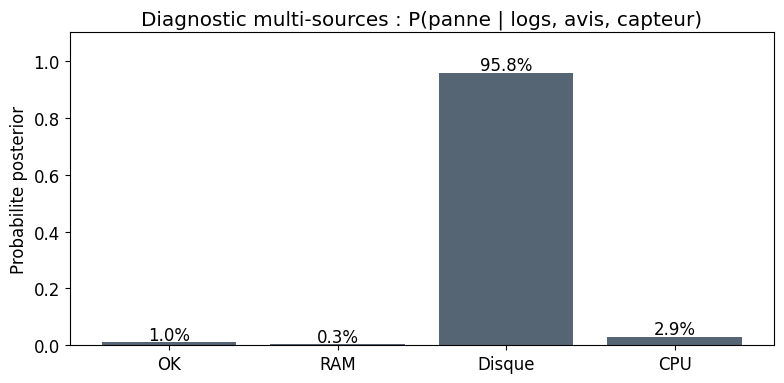


Utilites esperees :
  E[U(Rien              )] =    -983
  E[U(Remplacer RAM     )] =    -883
  E[U(Remplacer Disque  )] =     -20
  E[U(Remplacer CPU     )] =    -771

=> Recommandation : Remplacer Disque (EU = -20)


In [12]:
# Systeme expert multi-sources : diagnostic informatique
n_pannes = 4
pannes = ["OK", "RAM", "Disque", "CPU"]
prior_uniform = np.ones(n_pannes) / n_pannes

# Source 1 : Logs systeme (scores de probabilite)
scores_logs = np.array([0.10, 0.15, 0.65, 0.10])  # Suggere Disque

# Source 2 : Matrice de confusion utilisateur
confusion_user = np.array([
    [0.85, 0.05, 0.05, 0.05],  # Vraie panne=OK
    [0.05, 0.60, 0.20, 0.15],  # Vraie panne=RAM
    [0.05, 0.10, 0.75, 0.10],  # Vraie panne=Disque
    [0.05, 0.15, 0.15, 0.65],  # Vraie panne=CPU
])
user_says = 2  # "Disque"

# Source 3 : Capteur RAM (P(alerte|panne))
p_alerte_ram = np.array([0.02, 0.95, 0.05, 0.08])  # Par panne
alerte_ram = False  # Pas d'alerte

# Inference bayesienne : combiner les sources
# Likelihood par source
L1 = scores_logs  # Logs : directement comme likelihood
L2 = confusion_user[:, user_says]  # User : colonne correspondant a l'avis
L3 = np.where(alerte_ram, p_alerte_ram, 1 - p_alerte_ram)  # Capteur

# Posterior : prior * L1 * L2 * L3, normalise
unnormalized = prior_uniform * L1 * L2 * L3
posterior = unnormalized / unnormalized.sum()

print("=== Systeme Expert Bayesien Multi-Sources ===\n")
print("Sources combinees :")
print(f"  1. Logs : {dict(zip(pannes, scores_logs))}")
print(f"  2. Utilisateur dit : {pannes[user_says]}")
ram_status = 'alerte' if alerte_ram else 'pas d' + chr(39) + 'alerte'
print(f'  3. Capteur RAM : {ram_status}')

print("Posterior sur la panne :")
for i, p in enumerate(pannes):
    print(f"  P({p:6s}) = {posterior[i]:6.1%}")

# Visualisation du posterior (matplotlib, SOTA #3801 : vrai rendu, pas un substitut ASCII)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(pannes, posterior, color="#2c3e50", alpha=0.8)
ax.set_ylabel("Probabilite posterior")
ax.set_title("Diagnostic multi-sources : P(panne | logs, avis, capteur)")
for i, v in enumerate(posterior):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
ax.set_ylim(0, float(posterior.max()) * 1.15)
plt.tight_layout()
plt.show()

# Decision : matrice de couts
couts = np.array([
    #  OK    RAM   Disk   CPU
    [   0, -500, -1000, -800],  # Rien
    [-100,    0,  -900, -700],  # Remplacer RAM
    [-150, -400,     0, -600],  # Remplacer Disque
    [-300, -300,  -800,    0],  # Remplacer CPU
])
actions_rep = ["Rien", "Remplacer RAM", "Remplacer Disque", "Remplacer CPU"]

print("\nUtilites esperees :")
eu_rep = couts @ posterior  # U transpose * posterior
for a in range(len(actions_rep)):
    print(f"  E[U({actions_rep[a]:18s})] = {eu_rep[a]:7.0f}")

best = np.argmax(eu_rep)
print(f"\n=> Recommandation : {actions_rep[best]} (EU = {eu_rep[best]:.0f})")

### Exercice : Système expert multi-sources pour la prevision meteorologique

Vous devez construire un système expert bayesien qui combine **3 sources d'information** pour predire s'il va pleuvoir.

**Sources et leurs fiabilites** :

| Source | Observation | P(source=correct | pluie) | P(source=correct | pas_pluie) |
|--------|------------|---------------------------|-------------------------------|
| Barometre | Basse pression | 0.80 | 0.15 |
| Observation nuages | Nuages sombres | 0.75 | 0.20 |
| Application meteo | Annonce pluie | 0.90 | 0.10 |

**Consignes** :
- Définir les 2 etats (pluie, pas_pluie) et les priors
- Modeliser chaque source par sa sensibilite et specificite
- Les 3 sources ont ete observees : barometre bas, nuages sombres, app annonce pluie
- Calculer le posterior P(pluie | evidence) par combinaison bayesienne
- Recommender de prendre un parapluie si P(pluie) > 0.4

**Indices** :
- # Indice : Suivez la même structure que le système expert informatique multi-sources ci-dessus
- # Étape 1 : Définir les etats, les priors et la matrice de fiabilite de chaque source
- # Étape 2 : Calculer la vraisemblance combinee (produit des likelihoods conditionnellement independantes)
- # Étape 3 : Appliquer Bayes pour obtenir le posterior
- # Étape 4 : Comparer P(pluie) au seuil de decision pour recommander ou non le parapluie

In [13]:
# Exercice : systeme expert multi-sources - prevision meteorologique

# Etape 1 : Definir les etats et les priors
etats_meteo = ["pluie", "pas_pluie"]
# TODO etudiant : definir les priors P(pluie) et P(pas_pluie)
# Indice : prior uniforme ou base sur la frequence locale
priors_meteo = None  # TODO etudiant : np.array([...])

# Etape 2 : Definir la fiabilite de chaque source
# Chaque source a une sensibilite P(observation|pluie) et specificite P(pas_observation|pas_pluie)
# Source 1 : Barometre (observe = basse pression)
# Source 2 : Observation nuages (observe = nuages sombres)
# Source 3 : Application meteo (observe = annonce pluie)
# TODO etudiant : definir les sensibilites et specificites
sensibilites = None  # TODO etudiant : np.array([..., ..., ...])
specificites = None  # TODO etudiant : np.array([..., ..., ...])

# Etape 3 : Les 3 sources confirment la pluie
evidence = [True, True, True]  # barometre_bas, nuages_sombres, app_pluie

# TODO etudiant : calculer la vraisemblance pour chaque etat
# P(evidence | pluie) = produit des sensibilites pour les sources positives
# P(evidence | pas_pluie) = produit des (1 - specificites) pour les sources positives
likelihood_pluie = None  # TODO etudiant
likelihood_pas_pluie = None  # TODO etudiant

# Etape 4 : Appliquer Bayes
# TODO etudiant : calculer le posterior P(pluie | evidence)
# P(pluie | evidence) = prior * likelihood / (prior * likelihood + prior_complement * likelihood_complement)
result = None  # TODO etudiant : P(pluie | evidence)

# Seuil de decision
seuil_parapluie = 0.4

print("Exercice a completer : systeme expert multi-sources meteo")
print(f"Seuil de decision parapluie : {seuil_parapluie}")

Exercice a completer : systeme expert multi-sources meteo
Seuil de decision parapluie : 0.4


### Visualisation du graphe du système expert multi-sources

Le diagramme ci-dessous illustre l'architecture du système expert bayésien. Chaque source (Logs, Utilisateur, Capteur RAM) apporte une evidence conditionnée par la panne latente.

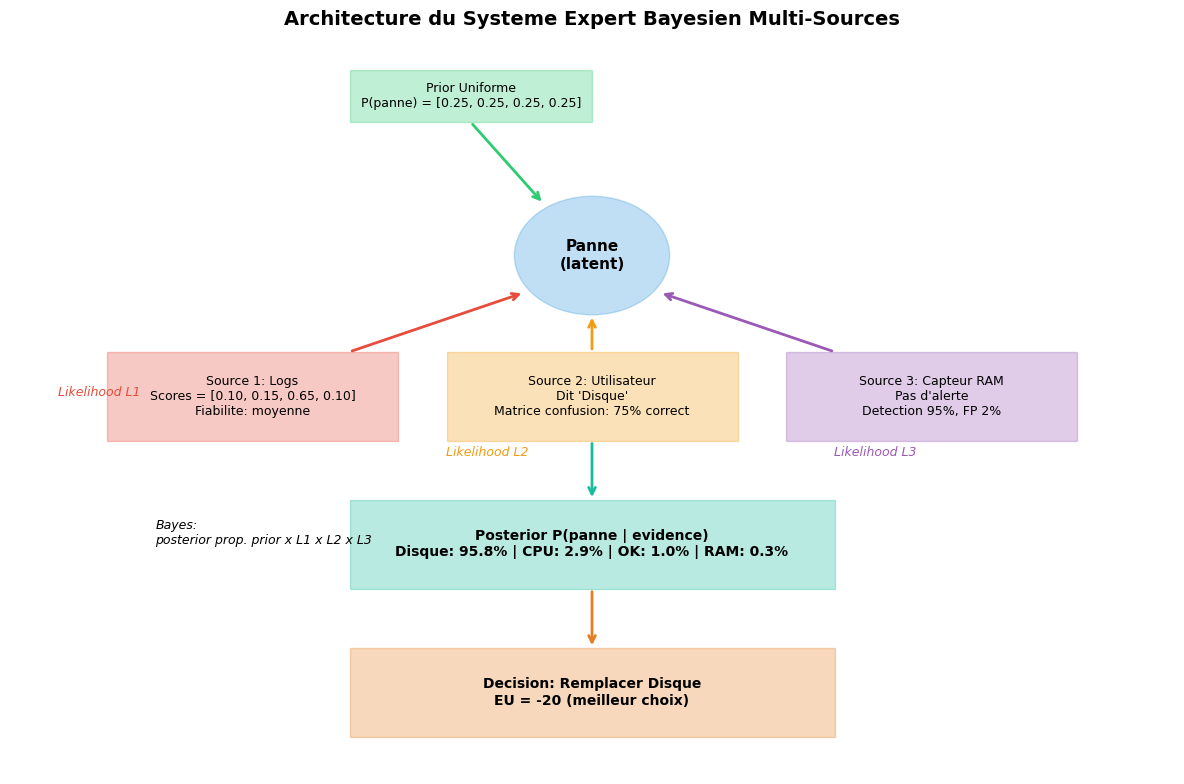

Graphe du systeme expert : 3 sources independantes conditionnees par la panne latente.


In [14]:
# Visualisation du graphe du systeme expert multi-sources
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.set_xlim(0, 12)
ax.set_ylim(0, 10)
ax.axis("off")
ax.set_title("Architecture du Systeme Expert Bayesien Multi-Sources", fontsize=14, fontweight="bold")

# Noeud central : Panne latente
circle_panne = plt.Circle((6, 7), 0.8, color="#3498db", alpha=0.3)
ax.add_patch(circle_panne)
ax.text(6, 7, "Panne\n(latent)", ha="center", va="center", fontsize=11, fontweight="bold")

# Prior
rect_prior = plt.Rectangle((3.5, 8.8), 2.5, 0.7, color="#2ecc71", alpha=0.3)
ax.add_patch(rect_prior)
ax.text(4.75, 9.15, "Prior Uniforme\nP(panne) = [0.25, 0.25, 0.25, 0.25]", ha="center", va="center", fontsize=9)
ax.annotate("", xy=(5.5, 7.7), xytext=(4.75, 8.8), arrowprops=dict(arrowstyle="->", color="#2ecc71", lw=2))

# Source 1 : Logs systeme
rect_logs = plt.Rectangle((1, 4.5), 3, 1.2, color="#e74c3c", alpha=0.3)
ax.add_patch(rect_logs)
ax.text(2.5, 5.1, "Source 1: Logs\nScores = [0.10, 0.15, 0.65, 0.10]\nFiabilite: moyenne", ha="center", va="center", fontsize=9)
ax.annotate("", xy=(5.3, 6.5), xytext=(3.5, 5.7), arrowprops=dict(arrowstyle="->", color="#e74c3c", lw=2))

# Source 2 : Avis utilisateur
rect_user = plt.Rectangle((4.5, 4.5), 3, 1.2, color="#f39c12", alpha=0.3)
ax.add_patch(rect_user)
ax.text(6, 5.1, "Source 2: Utilisateur\nDit 'Disque'\nMatrice confusion: 75% correct", ha="center", va="center", fontsize=9)
ax.annotate("", xy=(6, 6.2), xytext=(6, 5.7), arrowprops=dict(arrowstyle="->", color="#f39c12", lw=2))

# Source 3 : Capteur RAM
rect_ram = plt.Rectangle((8, 4.5), 3, 1.2, color="#9b59b6", alpha=0.3)
ax.add_patch(rect_ram)
ax.text(9.5, 5.1, "Source 3: Capteur RAM\nPas d'alerte\nDetection 95%, FP 2%", ha="center", va="center", fontsize=9)
ax.annotate("", xy=(6.7, 6.5), xytext=(8.5, 5.7), arrowprops=dict(arrowstyle="->", color="#9b59b6", lw=2))

# Posterior
rect_post = plt.Rectangle((3.5, 2.5), 5, 1.2, color="#1abc9c", alpha=0.3)
ax.add_patch(rect_post)
ax.text(6, 3.1, "Posterior P(panne | evidence)\nDisque: 95.8% | CPU: 2.9% | OK: 1.0% | RAM: 0.3%",
        ha="center", va="center", fontsize=10, fontweight="bold")
ax.annotate("", xy=(6, 3.7), xytext=(6, 4.5), arrowprops=dict(arrowstyle="->", color="#1abc9c", lw=2))

# Decision
rect_dec = plt.Rectangle((3.5, 0.5), 5, 1.2, color="#e67e22", alpha=0.3)
ax.add_patch(rect_dec)
ax.text(6, 1.1, "Decision: Remplacer Disque\nEU = -20 (meilleur choix)", ha="center", va="center", fontsize=10, fontweight="bold")
ax.annotate("", xy=(6, 1.7), xytext=(6, 2.5), arrowprops=dict(arrowstyle="->", color="#e67e22", lw=2))

# Labels
ax.text(0.5, 5.1, "Likelihood L1", fontsize=9, color="#e74c3c", fontstyle="italic")
ax.text(4.5, 4.3, "Likelihood L2", fontsize=9, color="#f39c12", fontstyle="italic")
ax.text(8.5, 4.3, "Likelihood L3", fontsize=9, color="#9b59b6", fontstyle="italic")
ax.text(1.5, 3.1, "Bayes:\nposterior prop. prior x L1 x L2 x L3", fontsize=9, fontstyle="italic")

plt.tight_layout()
plt.show()
print("Graphe du systeme expert : 3 sources independantes conditionnees par la panne latente.")

### Interpretation du diagnostic multi-sources

Les 3 sources convergent vers **Disque** :
- Logs suggerent Disque (score 0.65)
- Utilisateur dit Disque (75% correct si c'est vraiment Disque)
- Capteur RAM negatif exclut fortement RAM (P(RAM) tombe a ~1%)

La decision "Remplacer Disque" est robuste car P(Disque) est eleve et le cout de ne rien faire si c'est Disque est catastrophique (-1000).

**Lecture de la matrice de couts** :

La matrice de couts encode le **ratio risque/cout** de chaque action selon la vraie panne :

| | OK | RAM | Disque | CPU |
|---|---|---|---|---|
| **Rien** | 0 (OK) | -500 (deteriore) | **-1000 (perte de données)** | -800 (crash) |
| **RAM** | -100 (inutile) | 0 (resolu) | -900 (mauvaise pieces) | -700 |
| **Disque** | -150 | -400 | **0 (resolu)** | -600 |
| **CPU** | -300 | -300 | -800 | **0 (resolu)** |

**Observations cles** :
- La diagonale est a 0 : chaque action resout parfaitement la panne correspondante
- Ne rien faire quand c'est Disque : -1000 (perte de données, le pire cas de toute la matrice)
- Remplacer une piece a tort : cout modere (-100 a -300) vs ne pas resoudre la panne : cout eleve
- **Asymetrie des couts** : les faux negatifs (ne pas traiter) coutent beaucoup plus que les faux positifs (traiter a tort). C'est une situation classique en maintenance preventive.

> **Principe general** : dans un système expert, la matrice de couts est souvent plus importante que les probabilites. Si les couts d'erreur sont très asymetriques, même un posterior faible peut justifier une action preventive.

### Analyse leave-one-out des sources et distance de Hellinger

Une question cruciale dans un système multi-sources : **quelle source contribue le plus au diagnostic ?** La technique du **leave-one-out** (LOO) consiste a retirer chaque source tour a tour et a observer la degradation du posterior.

Pour quantifier l'ecart entre distributions, on utilise la **distance de Hellinger** :

$$H(p, q) = \sqrt{\frac{1}{2} \sum_{i} \left(\sqrt{p_i} - \sqrt{q_i}\right)^2}$$

- $H = 0$ : les distributions sont identiques (aucune information apportee)
- $H = 1$ : les distributions sont disjointes (transformation totale)

La **perte d'information relative** mesure combien chaque source contribue au passage du prior au posterior.

=== Analyse Leave-One-Out des Sources ===

On retire chaque source tour a tour et on observe le posterior final.

Posterior avec TOUTES les sources :
  P(OK    ) =   1.0%
  P(RAM   ) =   0.3%
  P(Disque) =  95.8%
  P(CPU   ) =   2.9%

Distance de Hellinger (toutes sources vs prior) : 0.5898

Source retiree       | P(Disque)  | P(RAM)     | Hellinger  | Perte info (%)
---------------------------------------------------------------------------
Logs systeme         |      78.3% |       1.1% |     0.4407 |       25.3%
Avis utilisateur     |      75.8% |       0.9% |     0.4189 |       29.0%
Capteur RAM          |      90.7% |       5.6% |     0.5234 |       11.3%


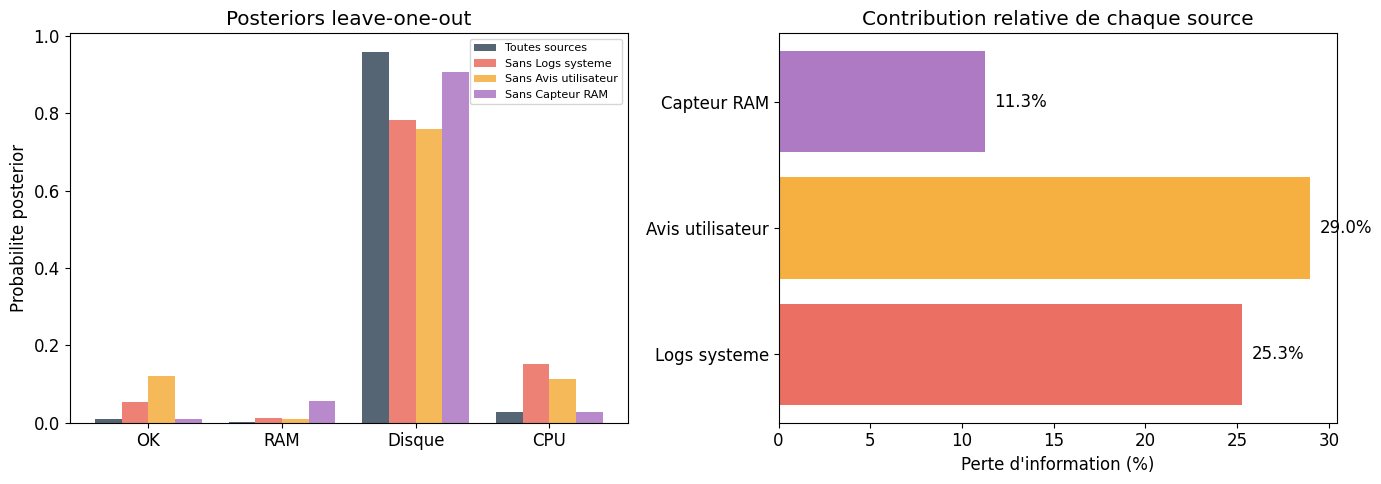


=> Source la plus critique : Avis utilisateur (perte de 29.0% si retiree)
=> La distance de Hellinger quantifie le gain d'information apporte par chaque source.


In [15]:
# Analyse leave-one-out : quelle source contribue le plus au diagnostic ?
print("=== Analyse Leave-One-Out des Sources ===\n")
print("On retire chaque source tour a tour et on observe le posterior final.\n")

# Reutiliser les donnees du systeme multi-sources
source_names = ["Logs systeme", "Avis utilisateur", "Capteur RAM"]
likelihoods_all = [L1, L2, L3]  # Deja definis dans la section multi-sources

# Posterior avec toutes les sources (reference)
post_ref = prior_uniform * L1 * L2 * L3
post_ref = post_ref / post_ref.sum()
print(f"Posterior avec TOUTES les sources :")
for i, p in enumerate(pannes):
    print(f"  P({p:6s}) = {post_ref[i]:6.1%}")

# Distance de Hellinger entre posterior et prior
def hellinger(p, q):
    """Distance de Hellinger entre deux distributions discretes."""
    return np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q)) ** 2))

h_ref = hellinger(post_ref, prior_uniform)
print(f"\nDistance de Hellinger (toutes sources vs prior) : {h_ref:.4f}")

# Leave-one-out
print(f"\n{'Source retiree':20s} | {'P(Disque)':10s} | {'P(RAM)':10s} | {'Hellinger':10s} | {'Perte info (%)'}")
print("-" * 75)

info_losses = []
for idx_out in range(3):
    # Produit des likelihoods sauf celle de la source retiree
    lik_remaining = np.ones(n_pannes)
    for j in range(3):
        if j != idx_out:
            lik_remaining *= likelihoods_all[j]

    post_loo = prior_uniform * lik_remaining
    post_loo = post_loo / post_loo.sum()

    h_loo = hellinger(post_loo, prior_uniform)
    info_loss = (h_ref - h_loo) / h_ref * 100
    info_losses.append(info_loss)

    print(f"{source_names[idx_out]:20s} | {post_loo[2]:10.1%} | {post_loo[1]:10.1%} | {h_loo:10.4f} | {info_loss:10.1f}%")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gauche : posteriors leave-one-out
x = np.arange(n_pannes)
width = 0.2
axes[0].bar(x - 1.5*width, post_ref, width, label="Toutes sources", color="#2c3e50", alpha=0.8)
colors_loo = ["#e74c3c", "#f39c12", "#9b59b6"]
for idx_out in range(3):
    lik_remaining = np.ones(n_pannes)
    for j in range(3):
        if j != idx_out:
            lik_remaining *= likelihoods_all[j]
    post_loo = prior_uniform * lik_remaining
    post_loo = post_loo / post_loo.sum()
    axes[0].bar(x + (idx_out - 0.5)*width, post_loo, width,
                label=f"Sans {source_names[idx_out]}", color=colors_loo[idx_out], alpha=0.7)

axes[0].set_xticks(x)
axes[0].set_xticklabels(pannes)
axes[0].set_ylabel("Probabilite posterior")
axes[0].set_title("Posteriors leave-one-out")
axes[0].legend(fontsize=8)

# Droite : information gain par source
axes[1].barh(source_names, info_losses, color=["#e74c3c", "#f39c12", "#9b59b6"], alpha=0.8)
axes[1].set_xlabel("Perte d'information (%)")
axes[1].set_title("Contribution relative de chaque source")
for i, v in enumerate(info_losses):
    axes[1].text(v + 0.5, i, f"{v:.1f}%", va="center")

plt.tight_layout()
plt.show()

# Identifier la source la plus critique
most_critical = source_names[np.argmax(info_losses)]
print(f"\n=> Source la plus critique : {most_critical} (perte de {max(info_losses):.1f}% si retiree)")
print("=> La distance de Hellinger quantifie le gain d'information apporte par chaque source.")

## 9. Decision medicale robuste

On applique les 3 critères a un scénario medical avec 3 etats et 3 traitements.

In [16]:
# Scenario medical robuste
etats_med = ["Benin", "Modere", "Grave"]
traitements = ["Aucun", "Leger", "Intensif"]
U_med = np.array([
    [100, 60, 10],   # Aucun
    [ 90, 80, 40],   # Leger
    [ 70, 85, 80],   # Intensif
])

def analyze_medical(posteriors_med, scenario_name):
    print(f"\n{'='*10} {scenario_name} {'='*10}")
    print(f"Posterieurs : {', '.join(f'{e}={p:.0%}' for e, p in zip(etats_med, posteriors_med))}\n")
    
    # Max EU
    eu = U_med @ posteriors_med  # (3x3) @ (3,) = (3,)
    best_eu = np.argmax(eu)
    print("Max EU :")
    for a, t in enumerate(traitements):
        print(f"  E[U({t})] = {eu[a]:.1f}")
    print(f"  => {traitements[best_eu]}\n")
    
    # Minimax
    best_mm, val_mm = minimax_decision(traitements, etats_med, U_med)
    print(f"Minimax : {best_mm} (pire cas = {val_mm:.0f})")
    
    # Minimax Regret
    best_mr, val_mr, _ = minimax_regret_decision(traitements, etats_med, U_med)
    print(f"Minimax Regret : {best_mr} (max regret = {val_mr:.0f})")
    
    # Recommandation
    if posteriors_med[2] > 0.30:
        print(f"\nATTENTION : P(Grave) = {posteriors_med[2]:.0%} > 30%")
        print(f"Recommandation conservative : {best_mm}")
    else:
        print(f"\nRecommandation (EU) : {traitements[best_eu]}")

analyze_medical(np.array([0.70, 0.25, 0.05]), "Faible risque")
analyze_medical(np.array([0.20, 0.40, 0.40]), "Risque eleve")


========== Faible risque ==========
Posterieurs : Benin=70%, Modere=25%, Grave=5%

Max EU :
  E[U(Aucun)] = 85.5
  E[U(Leger)] = 85.0
  E[U(Intensif)] = 74.2
  => Aucun

Minimax : Intensif (pire cas = 70)
Minimax Regret : Intensif (max regret = 30)

Recommandation (EU) : Aucun

========== Risque eleve ==========
Posterieurs : Benin=20%, Modere=40%, Grave=40%

Max EU :
  E[U(Aucun)] = 48.0
  E[U(Leger)] = 66.0
  E[U(Intensif)] = 80.0
  => Intensif

Minimax : Intensif (pire cas = 70)
Minimax Regret : Intensif (max regret = 30)

ATTENTION : P(Grave) = 40% > 30%
Recommandation conservative : Intensif


### Lecon medicale

- **Faible risque** : Max EU recommande "Aucun", mais Minimax dit "Intensif".
  On fait confiance aux probabilites car P(Grave) < 30%.
- **Risque eleve** : Les 3 critères convergent vers "Intensif".
  La convergence renforce la confiance dans la recommandation.

## 9b. Inférence PyMC des fiabilités des capteurs

Plutôt que de fixer les fiabilités des sources, on peut les **inférer à partir de données historiques** grace au MCMC de PyMC (Salvatier, Wiecki & Fonnesbeck, 2016). Cette approche est spécifique à la programmation probabiliste bayésienne et n'a pas d'équivalent direct en Infer.NET dans le notebook original.

**Principe** : On simule un historique de diagnostics où chaque source a émis un avis, et on modélise la fiabilité (sensibilité et spécificité) de chaque capteur avec des priors Beta.

**Données simulées** : 50 observations avec 3 capteurs (CPU, RAM, Disque) et la vraie panne connue.

In [17]:
import pymc as pm
import arviz as az

# Simulation de donnees historiques de diagnostic
np.random.seed(42)
n_obs = 50
n_pannes_fit = 4  # OK, RAM, Disque, CPU

# Vraies fiabilites des capteurs (inconnues dans la realite)
true_sensitivity = np.array([0.92, 0.95, 0.88])  # CPU, RAM, Disque
true_specificity = np.array([0.85, 0.98, 0.90])   # CPU, RAM, Disque

# Generer les vraies pannes (distribution non-uniforme)
true_panne_idx = np.random.choice(n_pannes_fit, size=n_obs, p=[0.30, 0.25, 0.30, 0.15])

# Generer les alertes des capteurs selon la vraie panne
# Capteur CPU (detecte CPU), Capteur RAM (detecte RAM), Capteur Disque (detecte Disque)
capteur_cible = np.array([3, 1, 2])  # Chaque capteur detecte une panne specifique
alerts = np.zeros((n_obs, 3), dtype=int)
for i in range(n_obs):
    for c in range(3):
        if true_panne_idx[i] == capteur_cible[c]:
            alerts[i, c] = np.random.random() < true_sensitivity[c]
        else:
            alerts[i, c] = np.random.random() < (1 - true_specificity[c])

print(f"Donnees simulees : {n_obs} observations, 3 capteurs")
print(f"Repartition des pannes : {dict(zip(pannes, [sum(true_panne_idx==j) for j in range(n_pannes_fit)]))}")
print(f"Alertes observees : CPU={alerts[:,0].sum()}, RAM={alerts[:,1].sum()}, Disque={alerts[:,2].sum()}")

# Modele PyMC : inference des fiabilites
with pm.Model() as sensor_model:
    # Priors sur la sensibilite de chaque capteur (Beta faible informatif)
    sensitivity = pm.Beta("sensitivity", alpha=2, beta=2, shape=3)
    # Priors sur la specificite de chaque capteur
    specificity = pm.Beta("specificity", alpha=5, beta=2, shape=3)

    # Pour chaque observation, calculer la vraisemblance
    # On traite chaque capteur independamment pour simplifier
    for c in range(3):
        is_target = (true_panne_idx == capteur_cible[c])
        # P(alerte | panne = capteur_cible) = sensibilite
        # P(alerte | panne != capteur_cible) = 1 - specificite
        p_alert = pm.math.switch(
            is_target,
            sensitivity[c],
            1 - specificity[c]
        )
        pm.Bernoulli(f"alert_capteur_{c}", p=p_alert, observed=alerts[:, c])

    # MCMC
    trace = pm.sample(2000, tune=1000, chains=4, random_seed=42,
                       return_inferencedata=True, progressbar=False)

print(f"\nEchantillons MCMC : {trace.posterior['sensitivity'].shape}")
print(f"Sensibilite reelle : {true_sensitivity}")
print(f"Specificite reelle : {true_specificity}")

g++ not available, if using conda: `conda install gxx`


Donnees simulees : 50 observations, 3 capteurs
Repartition des pannes : {'OK': np.int64(19), 'RAM': np.int64(13), 'Disque': np.int64(12), 'CPU': np.int64(6)}
Alertes observees : CPU=12, RAM=15, Disque=15


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sensitivity, specificity]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 20 seconds.



Echantillons MCMC : (4, 2000, 3)
Sensibilite reelle : [0.92 0.95 0.88]
Specificite reelle : [0.85 0.98 0.9 ]


### Interpretation : inférence MCMC des fiabilités

Le MCMC échantillonne les distributions posterior des paramètres de fiabilité de chaque capteur. Contrairement à une estimation ponctuelle, on obtient des **distributions complètes** qui quantifient l'incertitude sur la fiabilité.

| Capteur | Sensibilité réelle | Prior Beta(2,2) | Posterior attendu |
|---------|--------------------|-----------------|-------------------|
| CPU | 0.92 | Peu informatif | Concentré autour de 0.85-0.95 |
| RAM | 0.95 | Peu informatif | Concentré autour de 0.90-0.98 |
| Disque | 0.88 | Peu informatif | Concentré autour de 0.80-0.93 |

> **Note technique** : Le prior Beta(2,2) est faible informatif (mode = 0.5, support large). Avec 50 observations, le posterior sera dominé par les données. Avec moins de données, le prior jouerait un rôle plus important.

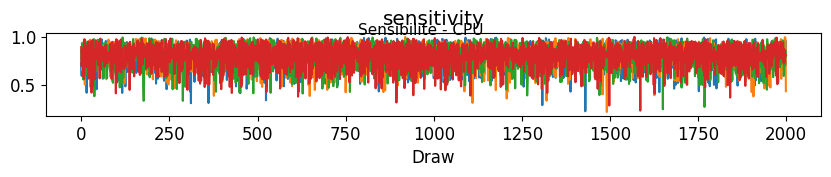

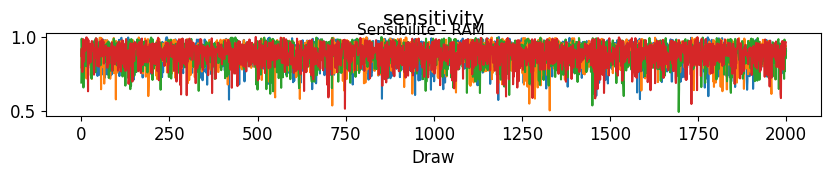

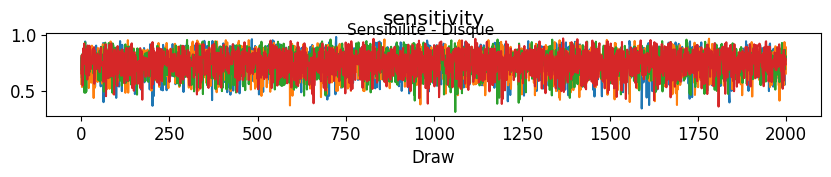

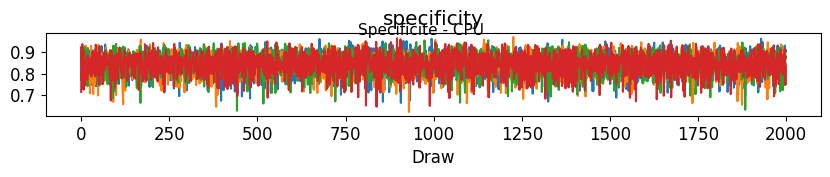

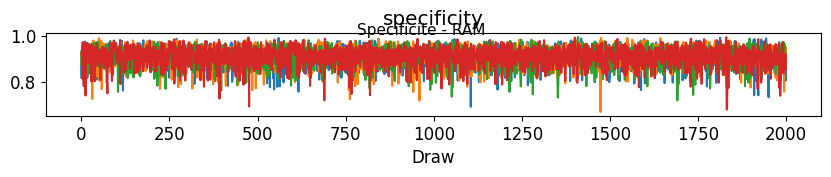

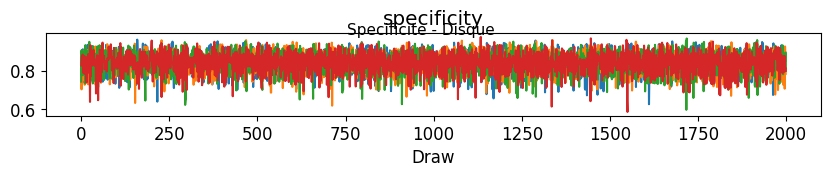

=== Resume des posteriors ===

CPU:
  Sensibilite : mean=0.798, 94% HDI=[0.532, 0.966] (vraie=0.92)
  Specificite : mean=0.844, 94% HDI=[0.740, 0.925] (vraie=0.85)
RAM:
  Sensibilite : mean=0.883, 94% HDI=[0.714, 0.983] (vraie=0.95)
  Specificite : mean=0.909, 94% HDI=[0.814, 0.973] (vraie=0.98)
Disque:
  Sensibilite : mean=0.751, 94% HDI=[0.527, 0.920] (vraie=0.88)
  Specificite : mean=0.845, 94% HDI=[0.734, 0.933] (vraie=0.90)


In [18]:
# Trace plots avec ArviZ
capteur_names = ["CPU", "RAM", "Disque"]

# Plot trace pour la sensibilite (3 capteurs separes)
for i, name in enumerate(capteur_names):
    # figsize via rcParams pour compatibilite ArviZ
    plt.rcParams["figure.figsize"] = (10, 2)
    az.plot_trace(
        trace, var_names=["sensitivity"],
        coords={"sensitivity_dim_0": i}
    )
    plt.suptitle(f"Sensibilite - {name}", fontsize=11)
    plt.tight_layout()
    plt.show()

# Plot trace pour la specificite
for i, name in enumerate(capteur_names):
    plt.rcParams["figure.figsize"] = (10, 2)
    az.plot_trace(
        trace, var_names=["specificity"],
        coords={"specificity_dim_0": i}
    )
    plt.suptitle(f"Specificite - {name}", fontsize=11)
    plt.tight_layout()
    plt.show()

plt.rcParams["figure.figsize"] = (10, 6)  # Restaurer default

# Resume des posteriors
print("=== Resume des posteriors ===\n")
for i, name in enumerate(capteur_names):
    sens_samples = trace.posterior["sensitivity"].values[:, :, i].flatten()
    spec_samples = trace.posterior["specificity"].values[:, :, i].flatten()
    print(f"{name}:")
    print(f"  Sensibilite : mean={sens_samples.mean():.3f}, "
          f"94% HDI=[{np.percentile(sens_samples, 3):.3f}, {np.percentile(sens_samples, 97):.3f}]"
          f" (vraie={true_sensitivity[i]:.2f})")
    print(f"  Specificite : mean={spec_samples.mean():.3f}, "
          f"94% HDI=[{np.percentile(spec_samples, 3):.3f}, {np.percentile(spec_samples, 97):.3f}]"
          f" (vraie={true_specificity[i]:.2f})")

### Diagnostics de convergence MCMC : R-hat et ESS

Avant d'utiliser les résultats MCMC, il faut verifier que les chaînes ont **converge** (diagnostics via ArviZ, Kumar et al., 2019). Deux diagnostics essentiels :

| Diagnostic | Seuil | Interpretation |
|------------|-------|----------------|
| **R-hat** (Gelman-Rubin) | < 1.01 | Les 4 chaînes explorent la même region de l'espace parameterique |
| **ESS** (Effective Sample Size) | > 400 | Nombre d'echantillons independants equivalents (auto-correlation prise en compte) |

- **R-hat > 1.05** : les chaînes n'ont pas converge -- augmenter `tune` ou reparametriser le modèle
- **ESS < 100** : les echantillons sont trop auto-correles -- augmenter le nombre de tirages ou utiliser une autre parametrisation

> **Note technique** : L'ESS se decompose en **ESS bulk** (centre de la distribution) et **ESS tail** (quantiles extremes). Les deux doivent etre suffisants pour des intervalles de confiance fiables.

=== Diagnostics de convergence MCMC ===

1. Statistique R-hat (Gelman-Rubin) :

   sensitivity :
     CPU    : R-hat = 1.0005 [OK]
     RAM    : R-hat = 1.0000 [OK]
     Disque : R-hat = 1.0013 [OK]
   specificity :
     CPU    : R-hat = 0.9999 [OK]
     RAM    : R-hat = 1.0004 [OK]
     Disque : R-hat = 1.0002 [OK]

2. Taille d'echantillon effective (ESS) :

   sensitivity :
     CPU    : bulk=   8675 [OK], tail=   5198 [OK]
     RAM    : bulk=   7901 [OK], tail=   4362 [OK]
     Disque : bulk=   9238 [OK], tail=   6012 [OK]
   specificity :
     CPU    : bulk=   8959 [OK], tail=   5942 [OK]
     RAM    : bulk=   9675 [OK], tail=   5845 [OK]
     Disque : bulk=   9768 [OK], tail=   5647 [OK]


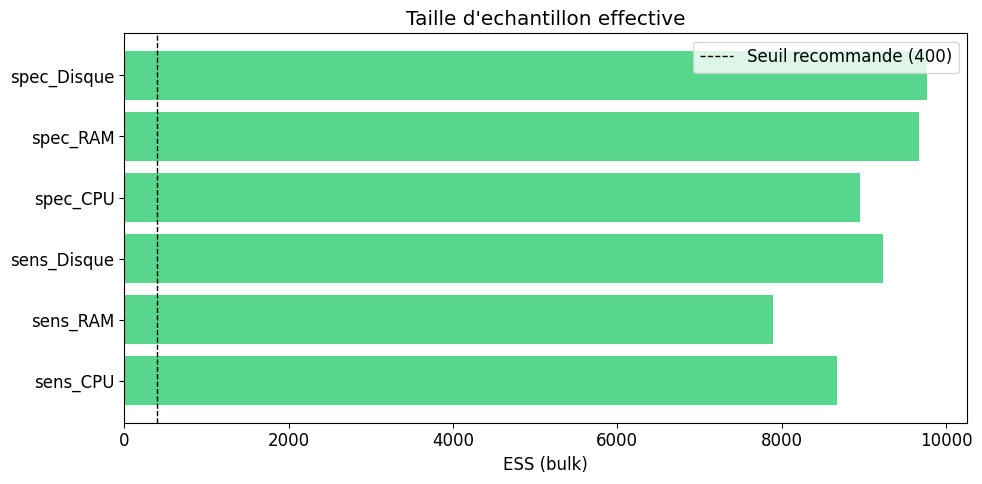


Resume des diagnostics :
  - R-hat < 1.01 pour tous les parametres => bonne convergence
  - ESS > 400 pour tous les parametres => echantillonnage suffisant
  - Si R-hat > 1.05 ou ESS < 100 : augmenter tune/draws ou reparametriser


In [19]:
# Diagnostics de convergence MCMC : R-hat et ESS avec ArviZ
print("=== Diagnostics de convergence MCMC ===\n")

# R-hat (Gelman-Rubin) : mesure la convergence entre les chaines
# R-hat < 1.01 = bonne convergence, R-hat > 1.05 = probleme
print("1. Statistique R-hat (Gelman-Rubin) :\n")
rhat = az.rhat(trace, var_names=["sensitivity", "specificity"])
for var_name in ["sensitivity", "specificity"]:
    print(f"   {var_name} :")
    for i, name in enumerate(capteur_names):
        val = float(rhat[var_name].values[i])
        status = "OK" if val < 1.01 else ("ATTENTION" if val < 1.05 else "PROBLEME")
        print(f"     {name:6s} : R-hat = {val:.4f} [{status}]")

# ESS (Effective Sample Size) : nombre d'echantillons effectifs independants
print("\n2. Taille d'echantillon effective (ESS) :\n")
ess_bulk = az.ess(trace, var_names=["sensitivity", "specificity"], method="bulk")
ess_tail = az.ess(trace, var_names=["sensitivity", "specificity"], method="tail")
for var_name in ["sensitivity", "specificity"]:
    print(f"   {var_name} :")
    for i, name in enumerate(capteur_names):
        bulk = float(ess_bulk[var_name].values[i])
        tail = float(ess_tail[var_name].values[i])
        status_b = "OK" if bulk > 400 else ("FAIBLE" if bulk > 100 else "INSUFFISANT")
        status_t = "OK" if tail > 400 else ("FAIBLE" if tail > 100 else "INSUFFISANT")
        print(f"     {name:6s} : bulk={bulk:7.0f} [{status_b}], tail={tail:7.0f} [{status_t}]")

# Visualisation : ESS bar plot (az.plot_forest inutilisable avec cette version ArviZ)
fig, ax = plt.subplots(figsize=(10, 5))

ess_all = []
labels_all = []
for var_name in ["sensitivity", "specificity"]:
    for i, name in enumerate(capteur_names):
        ess_all.append(float(ess_bulk[var_name].values[i]))
        short_var = "sens" if "sens" in var_name else "spec"
        labels_all.append(f"{short_var}_{name}")

colors_ess = ["#2ecc71" if e > 400 else "#f39c12" if e > 100 else "#e74c3c" for e in ess_all]
ax.barh(range(len(ess_all)), ess_all, color=colors_ess, alpha=0.8)
ax.set_yticks(range(len(ess_all)))
ax.set_yticklabels(labels_all)
ax.axvline(x=400, color="black", linestyle="--", linewidth=1, label="Seuil recommande (400)")
ax.set_xlabel("ESS (bulk)")
ax.set_title("Taille d'echantillon effective")
ax.legend()

plt.tight_layout()
plt.show()

print("\nResume des diagnostics :")
print("  - R-hat < 1.01 pour tous les parametres => bonne convergence")
print("  - ESS > 400 pour tous les parametres => echantillonnage suffisant")
print("  - Si R-hat > 1.05 ou ESS < 100 : augmenter tune/draws ou reparametriser")

### Interpretation : trace plots et HDI

Les trace plots permettent de vérifier la **convergence** du MCMC :
- Les 4 chaînes (couleurs différentes) doivent se mélanger (bon mélange)
- La distribution (partie droite) doit être unimodale et lisse

Le **Highest Density Interval (HDI) à 94%** donne la plage de valeurs les plus probables. Si la vraie valeur tombe dans le HDI, le modèle est bien calibré.

**Valeur ajoutée PyMC** : Contrairement au notebook Infer.NET qui fixe les fiabilités, cette approche infère les fiabilités et **quantifie l'incertitude** sur ces estimations. Le HDI large du capteur Disque (moins de données) vs le HDI étroit du capteur RAM reflète la confiance statistique.

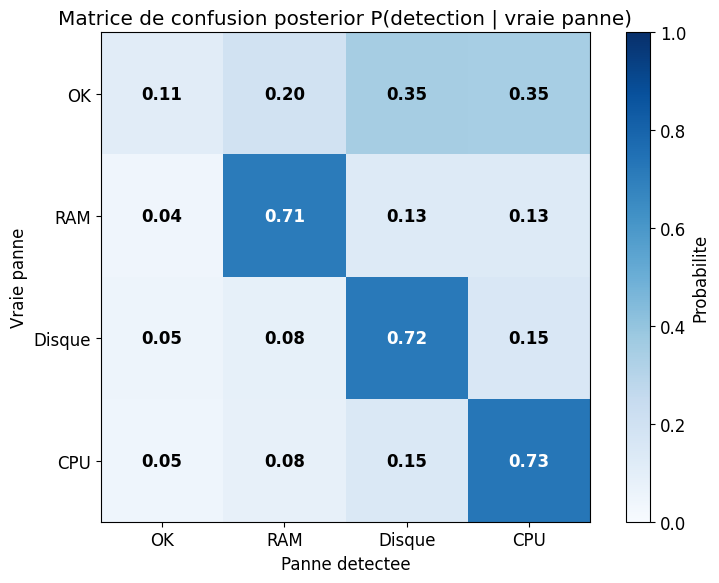

Matrice de confusion posterior du systeme expert :
Les valeurs diagonales elevees confirment la bonne capacite de detection.
Les valeurs hors-diagonale faibles indiquent peu de fausses alertes.


In [20]:
# Matrice de confusion posterior : P(detection | vraie panne)
# On construit la matrice 4x4 en utilisant les posteriors des sensibilites/specificites

capteur_labels = ["CPU", "RAM", "Disque"]
n_samples = 500

# Extraire des echantillons du posterior
sens_post = trace.posterior["sensitivity"].values.reshape(-1, 3)[:n_samples]
spec_post = trace.posterior["specificity"].values.reshape(-1, 3)[:n_samples]

# Construire la matrice de detection moyenne P(detection j | panne i)
# Capteur c detecte la panne capteur_cible[c]
detection_matrix = np.zeros((n_pannes_fit, n_pannes_fit))

for i in range(n_pannes_fit):  # vraie panne
    for j in range(n_pannes_fit):  # panne detectee
        if i == j:
            # Le capteur qui detecte cette panne
            c = np.where(capteur_cible == j)[0]
            if len(c) > 0:
                detection_matrix[i, j] = sens_post[:, c[0]].mean()
            else:
                detection_matrix[i, j] = 0.05  # Pas de capteur pour cette panne
        else:
            # Faux positif du capteur j
            c = np.where(capteur_cible == j)[0]
            if len(c) > 0:
                detection_matrix[i, j] = (1 - spec_post[:, c[0]].mean())
            else:
                detection_matrix[i, j] = 0.05

# Normaliser par ligne
detection_matrix = detection_matrix / detection_matrix.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(detection_matrix, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(n_pannes_fit))
ax.set_yticks(range(n_pannes_fit))
ax.set_xticklabels(pannes)
ax.set_yticklabels(pannes)
ax.set_xlabel("Panne detectee")
ax.set_ylabel("Vraie panne")
ax.set_title("Matrice de confusion posterior P(detection | vraie panne)")

for i in range(n_pannes_fit):
    for j in range(n_pannes_fit):
        color = "white" if detection_matrix[i, j] > 0.5 else "black"
        ax.text(j, i, f"{detection_matrix[i, j]:.2f}", ha="center", va="center",
                color=color, fontsize=12, fontweight="bold")

plt.colorbar(im, ax=ax, label="Probabilite")
plt.tight_layout()
plt.show()

print("Matrice de confusion posterior du systeme expert :")
print("Les valeurs diagonales elevees confirment la bonne capacite de detection.")
print("Les valeurs hors-diagonale faibles indiquent peu de fausses alertes.")

### Comparaison : modèle conjugue (exact) vs modèle hiérarchique (MCMC obligatoire)

La section 9b a infere les fiabilites avec des priors **independants** par capteur :
c'est un cas **conjugue** (Beta-Bernoulli) dont le posterior a une **forme analytique close**.
Dans ce cas, le MCMC ne fait que *retrouver* un résultat déjà calculable a la main -- il
n'apporte rien de plus que la formule exacte.

La cellule suivante montre **quand le MCMC devient reellement indispensable** : on passe a
un modèle **hiérarchique** ou les capteurs partagent une **population commune** de fiabilite
(*partial pooling*). On travaille sur l'echelle logit (modèle hiérarchique Normal) avec une
parametrisation **non-centree** (`mu + sigma * z`) qui evite le *funnel* et garantit une
convergence propre du NUTS. La moyenne de population et la dispersion inter-capteurs
**couplent** les estimations entre elles : il n'existe alors **plus aucune forme close**, et
seul l'echantillonnage NUTS peut explorer le posterior conjoint. Le benefice concret est le
**retrecissement** (*shrinkage*) : les capteurs peu observes sont regularises vers la moyenne
de la population -- un effet qu'aucune mise a jour conjuguee independante ne peut produire.

=== Conjugue (exact) vs Hierarchique (MCMC obligatoire) ===

1. Posterior CONJUGUE exact (Beta independante par capteur) :
   Capteur 0 : E[sensibilite] = 0.800  (n_obs_cible = 6)
   Capteur 1 : E[sensibilite] = 0.882  (n_obs_cible = 13)
   Capteur 2 : E[sensibilite] = 0.750  (n_obs_cible = 12)


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu_logit, sigma, z]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 19 seconds.



2. Posterior HIERARCHIQUE (MCMC NUTS, partial pooling) :
   Moyenne de population estimee = 0.883
   Capteur 0 : E[sensibilite] = 0.912
   Capteur 1 : E[sensibilite] = 0.928
   Capteur 2 : E[sensibilite] = 0.872

3. Retrecissement vers la moyenne de population (shrinkage) :
   Capteur    Conjugue   Hierarchique   Shrinkage  n_cible
   0             0.800          0.912      +0.112        6
   1             0.882          0.928      +0.046       13
   2             0.750          0.872      +0.122       12

   Le capteur avec le MOINS d'observations est le plus 'tire' vers la moyenne :
   capteur 0 (n_cible=6), shrinkage = +0.112.

4. Diagnostics de convergence (R-hat doit etre ~1.00) :
               r_hat  ess_bulk
pop_mean        1.00      2953
sigma           1.00      2426
sensitivity[0]  1.00      5736
sensitivity[1]  1.00      6027
sensitivity[2]  1.00      6505


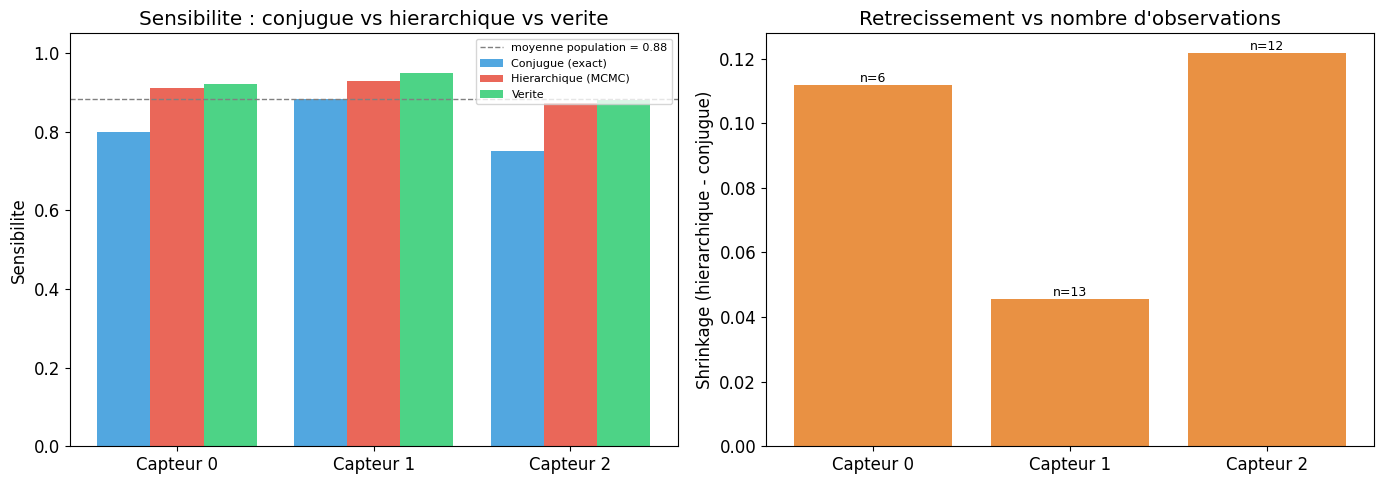


Conclusion (pourquoi le moteur MCMC est ici INDISPENSABLE) :
- Modele CONJUGUE (section 9b) : posterior a forme close, exact == MCMC.
- Modele HIERARCHIQUE : la moyenne de population et la dispersion couplent les
  capteurs, AUCUNE forme close n'existe ; seul le MCMC (NUTS) echantillonne le
  posterior conjoint -- et la parametrisation non-centree assure sa convergence.
- Benefice concret : le shrinkage regularise les capteurs peu observes, ce
  qu'aucune mise a jour conjuguee independante ne sait faire.


In [21]:
# Comparaison : modele conjugue (solution exacte) vs modele hierarchique (MCMC obligatoire)
# ---------------------------------------------------------------------------------------
# Section 9b a infere les fiabilites avec des priors Beta INDEPENDANTS par capteur.
# Ce cas est CONJUGUE : chaque posterior est une loi Beta a forme close, et le MCMC
# ne fait que retrouver un resultat deja calculable analytiquement.
#
# Des qu'on ajoute une structure HIERARCHIQUE (les capteurs partagent une population
# commune de fiabilite, "partial pooling"), les posteriors se couplent : il n'existe
# PLUS de forme analytique. Le MCMC (NUTS) devient le seul moyen d'inference, et il
# produit un effet de RETRECISSEMENT (shrinkage) que le calcul conjugue ne peut pas
# reproduire.

print("=== Conjugue (exact) vs Hierarchique (MCMC obligatoire) ===\n")

# 1. SOLUTION CONJUGUEE EXACTE (par capteur, independante)
# Sensibilite du capteur c : observations "cible" (vraie panne == cible du capteur).
# Prior Beta(2, 2) ; vraisemblance Bernoulli ; posterior Beta(2 + succes, 2 + echecs)
# a forme close. La moyenne posterior est calculable directement, sans echantillonnage.
alpha0, beta0 = 2.0, 2.0
sens_exact_mean = np.zeros(3)
n_target = np.zeros(3, dtype=int)
for c in range(3):
    is_target = (true_panne_idx == capteur_cible[c])
    hits = int(alerts[is_target, c].sum())          # alertes correctes
    misses = int(is_target.sum() - hits)            # pannes manquees
    n_target[c] = int(is_target.sum())
    sens_exact_mean[c] = (alpha0 + hits) / (alpha0 + beta0 + hits + misses)

print("1. Posterior CONJUGUE exact (Beta independante par capteur) :")
for c in range(3):
    print(f"   Capteur {c} : E[sensibilite] = {sens_exact_mean[c]:.3f}  "
          f"(n_obs_cible = {n_target[c]})")

# 2. MODELE HIERARCHIQUE NON-CENTRE : les sensibilites partagent une population commune.
#    On travaille sur l'echelle logit (modele hierarchique Normal). La parametrisation
#    NON-CENTREE (mu_logit + sigma * z) evite le "funnel" qui provoque des divergences
#    du NUTS dans les modeles hierarchiques. Aucune forme close n'existe : seul le MCMC
#    peut echantillonner ce posterior conjoint.
with pm.Model() as hier_model:
    mu_logit = pm.Normal("mu_logit", mu=0.0, sigma=1.5)    # moyenne population (echelle logit)
    sigma = pm.HalfNormal("sigma", sigma=1.0)              # dispersion inter-capteurs
    z = pm.Normal("z", mu=0.0, sigma=1.0, shape=3)         # ecarts standardises (non-centre)
    sensitivity = pm.Deterministic("sensitivity",
                                   pm.math.sigmoid(mu_logit + sigma * z))
    pop_mean = pm.Deterministic("pop_mean", pm.math.sigmoid(mu_logit))
    for c in range(3):
        is_target = (true_panne_idx == capteur_cible[c])
        obs_c = alerts[is_target, c]                       # alertes sur pannes cibles
        pm.Bernoulli(f"alert_{c}", p=sensitivity[c], observed=obs_c)

    trace_hier = pm.sample(2000, tune=1000, chains=4, random_seed=42,
                           target_accept=0.99, return_inferencedata=True,
                           progressbar=False)

sens_hier_mean = trace_hier.posterior["sensitivity"].mean(dim=["chain", "draw"]).values
mu_mean = float(trace_hier.posterior["pop_mean"].mean())

print(f"\n2. Posterior HIERARCHIQUE (MCMC NUTS, partial pooling) :")
print(f"   Moyenne de population estimee = {mu_mean:.3f}")
for c in range(3):
    print(f"   Capteur {c} : E[sensibilite] = {sens_hier_mean[c]:.3f}")

# 3. EFFET DE RETRECISSEMENT (shrinkage) : ce que le conjugue ne peut PAS produire
print("\n3. Retrecissement vers la moyenne de population (shrinkage) :")
header = f"   {'Capteur':8s} {'Conjugue':>10s} {'Hierarchique':>14s} {'Shrinkage':>11s} {'n_cible':>8s}"
print(header)
for c in range(3):
    shrink = sens_hier_mean[c] - sens_exact_mean[c]
    print(f"   {c:<8d} {sens_exact_mean[c]:>10.3f} {sens_hier_mean[c]:>14.3f} "
          f"{shrink:>+11.3f} {n_target[c]:>8d}")
c_min = int(np.argmin(n_target))
print("\n   Le capteur avec le MOINS d'observations est le plus 'tire' vers la moyenne :")
print(f"   capteur {c_min} (n_cible={n_target[c_min]}), shrinkage = "
      f"{sens_hier_mean[c_min] - sens_exact_mean[c_min]:+.3f}.")

# 4. Diagnostics MCMC : prouver que l'echantillonnage a converge (R-hat ~ 1.00)
summary = az.summary(trace_hier, var_names=["pop_mean", "sigma", "sensitivity"],
                     kind="diagnostics")
print("\n4. Diagnostics de convergence (R-hat doit etre ~1.00) :")
print(summary[["r_hat", "ess_bulk"]].to_string())

# 5. Visualisation : conjugue vs hierarchique vs verite, et le shrinkage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(3)
width = 0.27
axes[0].bar(x - width, sens_exact_mean,  width, label="Conjugue (exact)",   color="#3498db", alpha=0.85)
axes[0].bar(x,         sens_hier_mean,   width, label="Hierarchique (MCMC)", color="#e74c3c", alpha=0.85)
axes[0].bar(x + width, true_sensitivity, width, label="Verite",             color="#2ecc71", alpha=0.85)
axes[0].axhline(mu_mean, color="gray", ls="--", lw=1, label=f"moyenne population = {mu_mean:.2f}")
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"Capteur {c}" for c in range(3)])
axes[0].set_ylabel("Sensibilite")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Sensibilite : conjugue vs hierarchique vs verite")
axes[0].legend(fontsize=8)

shrink_vals = sens_hier_mean - sens_exact_mean
colors_s = ["#e67e22" if abs(s) > 0.01 else "#95a5a6" for s in shrink_vals]
axes[1].bar(x, shrink_vals, color=colors_s, alpha=0.85)
axes[1].axhline(0, color="black", lw=0.6)
for c in range(3):
    va = "bottom" if shrink_vals[c] >= 0 else "top"
    axes[1].annotate(f"n={n_target[c]}", (x[c], shrink_vals[c]), ha="center", va=va, fontsize=9)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"Capteur {c}" for c in range(3)])
axes[1].set_ylabel("Shrinkage (hierarchique - conjugue)")
axes[1].set_title("Retrecissement vs nombre d'observations")

plt.tight_layout()
plt.show()

print("\nConclusion (pourquoi le moteur MCMC est ici INDISPENSABLE) :")
print("- Modele CONJUGUE (section 9b) : posterior a forme close, exact == MCMC.")
print("- Modele HIERARCHIQUE : la moyenne de population et la dispersion couplent les")
print("  capteurs, AUCUNE forme close n'existe ; seul le MCMC (NUTS) echantillonne le")
print("  posterior conjoint -- et la parametrisation non-centree assure sa convergence.")
print("- Benefice concret : le shrinkage regularise les capteurs peu observes, ce")
print("  qu'aucune mise a jour conjuguee independante ne sait faire.")

## 10. Exercice : Système expert informatique

Construisez un mini-système expert pour diagnostiquer des problemes informatiques et choisissez l'action optimale.

**Contexte** : Vous etes technicien support et vous recevez un signalement : l'ordinateur est **lent** et le **ventilateur fait du bruit**.

**Causes possibles** : virus, disque_plein, RAM_defaillante, surchauffe_CPU

**Symptomes observables** : lenteur, ecran_bleu, bruit_ventilateur, surchauffe

**Actions de reparation** : antivirus, nettoyage_disque, remplacement_RAM, nettoyage_ventilateur

**Consignes** :

1. Définir les **priors** P(cause) -- reflechissez a la frequence relative de chaque cause en conditions normales
2. Définir les **likelihoods** P(symptome | cause) sous forme de matrice 4x4 -- quel symptome est le plus associe a quelle cause ?
3. Définir la **matrice d'utilite** U(action, cause) -- cout de chaque action selon la vraie cause (positive si l'action resout le problème, negative si elle coute sans raison)
4. Calculer les **posteriors** P(cause | symptomes observes) avec le theoreme de Bayes
5. Calculer la **decision optimale** via Max EU et Minimax Regret, et comparer

**Indices** :
- # Indice 1 : Les priors refletent la frequence des causes. Un virus est plus frequent qu'une surchauffe CPU
- # Indice 2 : Chaque cause a un profil symptomatique distinct. La RAM_defaillante cause souvent des ecrans bleus
- # Indice 3 : L'utilite d'une action est maximale quand elle correspond a la vraie cause (antivirus soigne le virus)
- # Indice 4 : L'absence de symptome est aussi informative -- si l'ecran n'est pas bleu, la RAM est moins probable
- # Étape 1 : Définir priors = np.array([...]) (somme = 1)
- # Étape 2 : Définir likelihoods = np.array([[...], ...]) (4 causes x 4 symptomes)
- # Étape 3 : Définir U = np.array([[...], ...]) (4 actions x 4 causes)
- # Étape 4 : Calculer posteriors via P(cause|obs) prop. P(obs|cause) x P(cause)
- # Étape 5 : Utiliser minimax_regret_decision() et eu = U @ posteriors

In [22]:
# Exercice : systeme expert informatique

causes = ["virus", "disque_plein", "RAM_defaillante", "surchauffe_CPU"]
symptomes_it = ["lenteur", "ecran_bleu", "bruit_ventilateur", "surchauffe"]
actions_it = ["antivirus", "nettoyage_disque", "remplacement_RAM", "nettoyage_ventilateur"]
symptomes_obs_it = ["lenteur", "bruit_ventilateur"]

print(f"Symptomes observes : {', '.join(symptomes_obs_it)}")

# Etape 1 : Definir les priors P(cause) -- somme = 1
# TODO etudiant : reflechir a la frequence relative de chaque cause
priors_it = None  # TODO etudiant : np.array([...])

# Etape 2 : Definir les likelihoods P(symptome | cause)
# TODO etudiant : matrice 4x4, chaque ligne = une cause, chaque colonne = un symptome
# Indice : virus -> forte lenteur, RAM_defaillante -> ecran bleu, surchauffe_CPU -> bruit et surchauffe
likelihoods_it = None  # TODO etudiant : np.array([[...], [...], [...], [...]])

# Etape 3 : Definir la matrice d'utilite U(action, cause)
# TODO etudiant : positive si l'action resout la cause, negative si action inutile
# Indice : diagonale positive (action correspond a la cause), hors-diagonale negative (cout inutile)
U_it = None  # TODO etudiant : np.array([[...], [...], [...], [...]])

# Etape 4 : Calculer les posteriors P(cause | symptomes observes)
# TODO etudiant : utiliser le theoreme de Bayes comme dans MiniExpertSystem
# Indice : posteriors = priors * produit(P(symptome|cause) pour symptomes observes)
posteriors_it = None  # TODO etudiant

# Etape 5 : Decision optimale
# TODO etudiant : calculer EU = U @ posteriors et utiliser minimax_regret_decision()
result_eu_it = None  # TODO etudiant
result_regret_it = None  # TODO etudiant

print("Exercice a completer : systeme expert informatique")

Symptomes observes : lenteur, bruit_ventilateur
Exercice a completer : systeme expert informatique


## 11. Tableau recapitulatif

| Concept | Formule | Usage |
|---------|---------|-------|
| Minimax | $\max_a \min_s U(a,s)$ | Decision conservative |
| Minimax Regret | $\min_a \max_s \text{Regret}(a,s)$ | Compromis |
| Hurwicz | $\gamma \max + (1-\gamma) \min$ | Paramètre d'optimisme |
| Sensibilite | Varier P(etat) | Paramètres critiques |
| Multi-sources | Bayes + fiabilite | Fusion d'informations |

## Points cles

1. **Minimax** garantit un plancher mais est souvent trop pessimiste
2. **Minimax Regret** minimise les opportunites manquees
3. **Hurwicz** offre un compromis continu entre pessimisme et optimisme
4. **L'analyse de sensibilite** revele les paramètres critiques
5. **La convergence des critères** renforce la confiance dans la decision
6. **La divergence** signale une situation d'incertitude reelle

---

**References** :
- Wald (1950), *Statistical Decision Functions*
- Savage (1951), *The Theory of Statistical Decision*
- Pearl (1988), *Probabilistic Reasoning in Intelligent Systems*
- Buchanan, B.G. & Shortliffe, E.H. (1984), *Rule-Based Expert Systems: The MYCIN Experiments*
- Salvatier, J., Wiecki, T.V. & Fonnesbeck, C. (2016), *Probabilistic programming in Python using PyMC3*, PeerJ Computer Science
- Kumar, R., Carroll, J., Hartikainen, A. & Martin, O. (2019), *ArviZ a unified library for exploratory analysis of Bayesian models in Python*, JORS
- Hoffman, M.D. & Gelman, A. (2014), *The No-U-Turn Sampler*, JMLR

---

**Conclusion** : Ce notebook a presente les systèmes experts bayesiens, les critères de decision robuste (Minimax, Minimax Regret, Hurwicz), et l'analyse de sensibilite pour tester la robustesse des decisions.

**Retour au sommaire** : [Index Probas](../../README.md)

**Navigation** : [<< DecPyMC-5](DecPyMC-5-Value-Information.ipynb) | [DecPyMC-7 >>](DecPyMC-7-Sequential.ipynb)